In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.io import loadmat
from collections import Counter
from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List
from scipy.stats import weibull_min
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from tensorflow.keras.utils import to_categorical
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, log_loss, roc_curve, auc,
    precision_recall_curve, average_precision_score, r2_score
)

# =========================================================
# GPU CONFIG
# =========================================================
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        try:
            tf.config.experimental.set_memory_growth(device, True)
        except RuntimeError as e:
            print(f" {e}")
    print(f"GPU is available: {physical_devices}")
else:
    print("No GPU found. Using CPU.")

# Reproducibility (optional)
np.random.seed(42)
tf.random.set_seed(42)

# =========================================================
# USER CONFIG
# =========================================================
base_root  = r"C:\Users\user\Documents\Imam_Sya_roni\SWD_Machine_Learning\SWD_DB_ChamberMatched"
excel_path = r"C:\Users\user\Documents\Imam_Sya_roni\SWD_Machine_Learning\Laboratory Test Result.xlsx"
plate      = "Plate1"  # "Plate 1/3"

# Sensor sampling
dt_sec  = 20.0
dt_days = dt_sec / 86400.0

# Failure definition (Hz drop)
drop_pct         = 0.10      # 10% drop from baseline
baseline_minutes = 60.0
dwell_minutes    = 10.0

# Training
test_size   = 0.20
val_size    = 0.20   # val portion of TRAIN
random_state = 42
epochs      = 30
batch_size  = 64

# RCM
horizon_days      = 30.0
base_severity_S   = 9
failure_mode_name = f"Runway standing water sensor degradation ({plate})"

class_names = ["Very High", "High", "High, frequently", "Failure Stad 1", "Failure Stad 2"]

# =========================================================
# 1) DATA LOADER
# =========================================================
def infer_length_from_padding(X: np.ndarray, pad_value: float = 0.0) -> np.ndarray:
    mask = np.abs(X - pad_value) > 1e-12
    L = np.zeros((X.shape[0],), dtype=np.int32)
    for i in range(X.shape[0]):
        idx = np.where(mask[i])[0]
        L[i] = (idx[-1] + 1) if idx.size > 0 else 0
    return L

def load_multiple_mat_files(directory: str) -> Tuple[List[np.ndarray], List[Optional[np.ndarray]]]:
    X_list, L_list = [], []
    for filename in os.listdir(directory):
        if not filename.endswith(".mat"):
            continue
        file_path = os.path.join(directory, filename)
        try:
            mat = loadmat(file_path)
            if "durability" not in mat:
                continue
            X = np.asarray(mat["durability"], dtype=np.float32)
            if X.ndim != 2:
                continue

            L = None
            if "durability_len" in mat:
                Ltmp = np.asarray(mat["durability_len"], dtype=np.int32).reshape(-1, 1)
                if Ltmp.shape[0] == X.shape[0]:
                    L = Ltmp
            X_list.append(X)
            L_list.append(L)
        except Exception as e:
            print(f"Failed to load {filename}: {e}")
    return X_list, L_list

# =========================================================
# 2) TRANSQ + QUANTUM MODEL ( model, with safe positional embedding)
# =========================================================
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
import pennylane as qml
from pennylane.qnn import KerasLayer

n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="tf", diff_method="backprop")
def quantum_circuit(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.templates.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

weight_shapes = {"weights": (3, n_qubits)}
quantum_layer = KerasLayer(quantum_circuit, weight_shapes, output_dim=n_qubits)

def quantum_model_block(x_vec):
    x = layers.Dense(n_qubits)(x_vec)
    x = layers.LayerNormalization()(x)
    x = layers.Lambda(lambda t: np.pi * tf.tanh(t))(x)  # stabilize to [-pi, pi]
    q = quantum_layer(x)
    q = layers.Dense(64, activation="relu")(q)
    return q

def transformer_block(x, num_heads=4, key_dim=32, ff_dim=256, dropout=0.3, l2reg=1e-4):
    h = layers.LayerNormalization(epsilon=1e-6)(x)
    h = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(h, h)
    h = layers.Dropout(dropout)(h)
    x = layers.Add()([x, h])

    h = layers.LayerNormalization(epsilon=1e-6)(x)
    h = layers.Dense(ff_dim, activation="relu", kernel_regularizer=regularizers.l2(l2reg))(h)
    h = layers.Dropout(dropout)(h)
    h = layers.Dense(x.shape[-1], kernel_regularizer=regularizers.l2(l2reg))(h)
    x = layers.Add()([x, h])
    return x

class PositionalEmbedding1D(layers.Layer):
    def __init__(self, max_len: int, embed_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.embed_dim = embed_dim
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        # x: (batch, T, C)
        T = tf.shape(x)[1]
        positions = tf.range(start=0, limit=T, delta=1)          # (T,)
        pos = self.pos_emb(positions)                            # (T, C)
        pos = tf.expand_dims(pos, axis=0)                        # (1, T, C)
        return x + pos                                           # broadcast to (batch, T, C)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"max_len": self.max_len, "embed_dim": self.embed_dim})
        return cfg
def build_1d_transq_model(input_len=951, num_classes=5, patch_size=21, embed_dim=128):
    inp = layers.Input(shape=(input_len,), name="signal")
    x = layers.Reshape((input_len, 1))(inp)

    x = layers.Conv1D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="same")(x)
    x = PositionalEmbedding1D(max_len=2048, embed_dim=embed_dim, name="pos_emb")(x)

    x = transformer_block(x)
    x = transformer_block(x)

    cls = layers.GlobalAveragePooling1D()(x)
    cls = layers.Dense(64, activation="relu")(cls)

    q = quantum_model_block(inp)

    fused = layers.Concatenate()([cls, q])          # (batch, 128)
    gate  = layers.Dense(128, activation="sigmoid")(fused)
    fused = layers.Multiply()([fused, gate])

    h = layers.Dense(128, activation="relu")(fused)
    h = layers.Dropout(0.4)(h)
    out = layers.Dense(num_classes, activation="softmax")(h)

    model = models.Model(inp, out, name="TransQ_1D_Fused")
    model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# =========================================================
# 3) ALT EXTRACTION (Hz drop) FROM EXCEL
# =========================================================
def read_chamber_series(excel_path: str, sheet: str, plate: str) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_excel(excel_path, sheet_name=sheet, header=None)
    data = df.iloc[2:, :3].copy()
    data.columns = ["days", "single", "three"]
    data = data.dropna(subset=["days"])
    t_days = data["days"].astype(float).to_numpy()

    hz = data["single"].astype(float).to_numpy() if plate == "Plate1" else data["three"].astype(float).to_numpy()

    ok = ~np.isnan(t_days) & ~np.isnan(hz)
    return t_days[ok], hz[ok]

def extract_failure_time_days_from_time_axis(
    t_days: np.ndarray,
    hz: np.ndarray,
    test_duration_days: float,
    drop_pct: float,
    baseline_minutes: float,
    dwell_minutes: float,
) -> Tuple[float, int, float]:
    t = np.asarray(t_days, float)
    f = np.asarray(hz, float)
    if t.size == 0:
        return test_duration_days, 0, np.nan

    baseline_days = baseline_minutes / (24.0 * 60.0)
    base_idx = np.where(t <= (t[0] + baseline_days))[0]
    if base_idx.size == 0:
        base_idx = np.arange(min(5, t.size))
    f0 = float(np.mean(f[base_idx]))

    thr = f0 * (1.0 - float(drop_pct))
    dwell_days = dwell_minutes / (24.0 * 60.0)

    below = (f <= thr)
    i = 0
    while i < t.size:
        if below[i]:
            j = i
            while j < t.size and below[j]:
                j += 1
            dur = t[j-1] - t[i]
            if dur >= dwell_days:
                return float(min(t[i], test_duration_days)), 1, float(thr)
            i = j
        else:
            i += 1

    return float(test_duration_days), 0, float(thr)

def get_alt_from_excel(excel_path: str, plate: str) -> Dict[str, Dict[str, float]]:
    # Temperature (7 days)
    tT, hzT = read_chamber_series(excel_path, "Chamber Temperature Test", plate)
    t_fail_T, event_T, thr_T = extract_failure_time_days_from_time_axis(
        tT, hzT, 7.0, drop_pct, baseline_minutes, dwell_minutes
    )

    # Humidity (21 days)
    tH, hzH = read_chamber_series(excel_path, "Chamber Humidity Test", plate)
    t_fail_H, event_H, thr_H = extract_failure_time_days_from_time_axis(
        tH, hzH, 21.0, drop_pct, baseline_minutes, dwell_minutes
    )

    return {
        "temperature": {"t_fail_days": t_fail_T, "event": event_T, "thr_used": thr_T},
        "humidity":    {"t_fail_days": t_fail_H, "event": event_H, "thr_used": thr_H},
    }

# =========================================================
# 4) RELIABILITY + RCM (with censored-aware eta when beta fixed/estimated)
# =========================================================
@dataclass
class WeibullModel:
    beta: float
    eta: float

    def cdf(self, t: np.ndarray) -> np.ndarray:
        return weibull_min.cdf(t, c=self.beta, scale=self.eta)

    def p_fail_horizon(self, t_now: float, delta_t: float) -> float:
        return float(self.cdf(np.array([t_now + delta_t]))[0] - self.cdf(np.array([t_now]))[0])

def fit_beta_from_failures_only(fail_times: np.ndarray) -> float:
    # Weibull fit on failures only (no censoring), loc fixed to 0
    beta, loc, eta = weibull_min.fit(fail_times, floc=0)
    return float(beta)

def eta_mle_censored_beta_fixed(times: np.ndarray, events: np.ndarray, beta: float) -> float:
    # MLE eta with right-censoring when beta fixed:
    # eta^beta = sum(t_i^beta) / d, where d = number of failures
    times = np.asarray(times, float)
    events = np.asarray(events, int)
    d = int(np.sum(events == 1))
    if d <= 0:
        raise ValueError("No failures (d=0), cannot estimate eta with this formula.")
    sum_tbeta = float(np.sum(times ** beta))
    eta = (sum_tbeta / d) ** (1.0 / beta)
    return float(eta)

def build_weibull_from_alt(times: np.ndarray, events: np.ndarray, beta_assumed: float = 2.0) -> Tuple[WeibullModel, str]:
    times = np.asarray(times, float)
    events = np.asarray(events, int)

    fail_times = times[events == 1]
    if fail_times.size >= 2:
        beta = fit_beta_from_failures_only(fail_times)
        eta  = eta_mle_censored_beta_fixed(times, events, beta)
        return WeibullModel(beta=beta, eta=eta), "Weibull: beta from failures (>=2), eta censored-MLE."
    elif fail_times.size == 1:
        beta = float(beta_assumed)
        eta  = eta_mle_censored_beta_fixed(times, events, beta)  # uses censored info to enlarge eta
        return WeibullModel(beta=beta, eta=eta), "Weibull: beta assumed (=2.0), eta censored-MLE (uses humidity censored)."
    else:
        # no failure detected: fallback eta from max censor time
        beta = float(beta_assumed)
        eta  = float(np.max(times)) / (np.log(2.0) ** (1.0 / beta))  # median ~ max censor (rough)
        return WeibullModel(beta=beta, eta=eta), "Weibull: no failures, fallback eta from censor horizon."

def ai_predict_proba(model, X: np.ndarray) -> np.ndarray:
    return np.asarray(model.predict(X, verbose=0))

def detection_metrics_from_confusion(y_true: np.ndarray, y_pred: np.ndarray, positive_class: int) -> Dict[str, float]:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.sum((y_true == positive_class) & (y_pred == positive_class))
    fn = np.sum((y_true == positive_class) & (y_pred != positive_class))
    recall = tp / (tp + fn + 1e-12)
    fnr = 1.0 - recall
    return {"recall": float(recall), "fnr": float(fnr)}

@dataclass
class FMEAItem:
    failure_mode: str
    severity_S: int
    occurrence_O: int
    detection_D: int
    rpn: int = 0

    def compute_rpn(self) -> int:
        self.rpn = int(self.severity_S * self.occurrence_O * self.detection_D)
        return self.rpn

def map_probability_to_occurrence(prob: float) -> int:
    prob = float(np.clip(prob, 0.0, 1.0))
    # horizon probability bins
    if prob <= 0.001: return 1
    if prob <= 0.005: return 2
    if prob <= 0.01:  return 3
    if prob <= 0.03:  return 4
    if prob <= 0.05:  return 5
    if prob <= 0.10:  return 6
    if prob <= 0.20:  return 7
    if prob <= 0.40:  return 8
    if prob <= 0.70:  return 9
    return 10


def map_fnr_to_detection(fnr: float) -> int:
    fnr = float(np.clip(fnr, 0.0, 1.0))
    if fnr <= 0.01: return 1
    if fnr <= 0.03: return 2
    if fnr <= 0.05: return 3
    if fnr <= 0.08: return 4
    if fnr <= 0.12: return 5
    if fnr <= 0.18: return 6
    if fnr <= 0.25: return 7
    if fnr <= 0.35: return 8
    if fnr <= 0.50: return 9
    return 10

def ap_level_from_rpn(rpn: int) -> str:
    if rpn >= 300: return "AP1-Immediate"
    if rpn >= 180: return "AP2-Urgent"
    if rpn >= 90:  return "AP3-Plan"
    return "AP4-Monitor"

def fused_fail_prob_alt(weibull, t_now_alt_days: float, delta_alt_days: float,
                        p_critical: float, gamma: float = 2.0) -> float:
    """
    Δt-aware fusion:
    - Weibull gives baseline probability of failure in (t, t+Δt]
    - AI-agent p_critical inflates hazard by multiplier m = 1 + gamma*p_critical
    """
    p_base = float(weibull.p_fail_horizon(t_now=t_now_alt_days, delta_t=delta_alt_days))
    p_critical = float(np.clip(p_critical, 0.0, 1.0))
    m = 1.0 + gamma * p_critical

    # For small probabilities
    p = min(1.0, m * p_base)
    return p


def recommend_interval_days_field(weibull, t_now_field_days: float, p_critical: float,
                                 k_field_to_alt: float,
                                 target_p_fail: float = 0.10,
                                 max_days_field: float = 180.0,
                                 gamma: float = 2.0) -> float:
    """
    Find max FIELD interval such that fused_fail_prob_alt <= target_p_fail.
    Uses ALT-equivalent time via k scaling.
    """
    if max_days_field <= 0:
        return 0.0

    t_now_alt = k_field_to_alt * float(t_now_field_days)

    # check 1 day
    p1 = fused_fail_prob_alt(
        weibull, t_now_alt_days=t_now_alt,
        delta_alt_days=k_field_to_alt * 1.0,
        p_critical=p_critical, gamma=gamma
    )
    if p1 > target_p_fail:
        return 0.0

    lo, hi = 0.0, float(max_days_field)
    for _ in range(40):
        mid = (lo + hi) / 2.0
        p = fused_fail_prob_alt(
            weibull, t_now_alt_days=t_now_alt,
            delta_alt_days=k_field_to_alt * mid,
            p_critical=p_critical, gamma=gamma
        )
        if p <= target_p_fail:
            lo = mid
        else:
            hi = mid
    return float(lo)


def maintenance_policy(ap_level: str, recommended_interval_days: float) -> Dict[str, object]:
    # action from AP level
    if ap_level == "AP1-Immediate":
        return {"action": "Replace/Remove from service", "interval_days": 0}
    if ap_level == "AP2-Urgent":
        return {"action": "Inspect + Calibrate + Reduce interval", "interval_days": int(np.ceil(recommended_interval_days))}
    if ap_level == "AP3-Plan":
        return {"action": "Scheduled inspection", "interval_days": int(np.ceil(recommended_interval_days))}
    return {"action": "Monitor", "interval_days": int(np.ceil(recommended_interval_days))}

def estimate_k_from_survival(weibull, t_field_days: float, S_target: float = 0.90) -> float:
    """
    Kalibrasi acceleration factor k dari fakta 'sensor survive sampai t_field_days'.
    Asumsi: pada umur sekarang, survival di skala ALT-equivalent ~ S_target.
    S(t) = exp(-(t/eta)^beta) = S_target
    => t_alt = eta * (-ln(S_target))^(1/beta)
    => k = t_alt / t_field_days
    """
    t_field_days = float(t_field_days)
    if t_field_days <= 0:
        raise ValueError("t_field_days must be > 0")

    beta = float(weibull.beta)
    eta  = float(weibull.eta)

    if not (0.0 < S_target < 1.0):
        raise ValueError("S_target must be between 0 and 1 (exclusive)")

    t_alt = eta * ((-np.log(S_target)) ** (1.0 / beta))
    k = t_alt / t_field_days
    # guard (avoid zero)
    return float(max(k, 1e-12))


@dataclass
class FrameworkConfig:
    horizon_days: float
    critical_class_index: int
    failure_mode_name: str

class AIinformedRCMFramework:
    def __init__(self, config: FrameworkConfig, weibull: WeibullModel):
        self.config = config
        self.weibull = weibull

    def run_decision(
        self,
        model,
        X: np.ndarray,
        y_true_class: np.ndarray,
        base_severity_S: int,
        simulate_field_2y: bool = True,
        t_now_field_days: float = 365.0 * 2,
        S_target: float = 0.90,
        target_p_fail: float = 0.10,
        max_days_field: float = 180.0,
        gamma: float = 2.0,
        D_fixed: int = 1, 
    ):
        proba = ai_predict_proba(model, X)
        y_pred = np.argmax(proba, axis=1)

        # Detection (deployment-safe)
        if y_true_class is None:
            det = {"recall": np.nan, "fnr": np.nan}
            D = int(D_fixed)
        else:
            det = detection_metrics_from_confusion(y_true_class, y_pred, self.config.critical_class_index)
            D = map_fnr_to_detection(det["fnr"])

        p_critical = float(np.mean(proba[:, self.config.critical_class_index]))

        # ---- Field simulation (2 years) ----
        if simulate_field_2y:
            k = estimate_k_from_survival(self.weibull, t_field_days=t_now_field_days, S_target=S_target)
            t_now_alt = k * float(t_now_field_days)
            horizon_alt = k * float(self.config.horizon_days)

            p_fail_base = float(self.weibull.p_fail_horizon(t_now=t_now_alt, delta_t=horizon_alt))

            recommended_field = recommend_interval_days_field(
                weibull=self.weibull,
                t_now_field_days=float(t_now_field_days),
                p_critical=p_critical,
                k_field_to_alt=k,
                target_p_fail=target_p_fail,
                max_days_field=max_days_field,
                gamma=gamma
            )
        else:
            # ALT-time direct mode
            k = np.nan
            t_now_alt = np.nan
            horizon_alt = np.nan
            p_fail_base = float(self.weibull.p_fail_horizon(t_now=0.0, delta_t=self.config.horizon_days))
            recommended_field = np.nan

        # Δt-aware fused risk for your chosen planning horizon
        if simulate_field_2y:
            p_fail = fused_fail_prob_alt(
                self.weibull,
                t_now_alt_days=t_now_alt,
                delta_alt_days=horizon_alt,
                p_critical=p_critical,
                gamma=gamma
            )
        else:
            p_fail = 1.0 - (1.0 - p_fail_base) * (1.0 - p_critical)  # legacy

        O = map_probability_to_occurrence(p_fail)

        fmea = FMEAItem(
            failure_mode=self.config.failure_mode_name,
            severity_S=int(base_severity_S),
            occurrence_O=int(O),
            detection_D=int(D)
        )
        rpn = fmea.compute_rpn()
        ap = ap_level_from_rpn(rpn)

        plan = maintenance_policy(ap, recommended_interval_days=recommended_field if simulate_field_2y else self.config.horizon_days)

        debug = {
            "simulate_field_2y": bool(simulate_field_2y),
            "S_target": float(S_target),
            "t_now_field_days": float(t_now_field_days) if simulate_field_2y else np.nan,
            "k_field_to_alt": float(k) if simulate_field_2y else np.nan,
            "t_now_alt_equiv_days": float(t_now_alt) if simulate_field_2y else np.nan,
            "horizon_alt_equiv_days": float(horizon_alt) if simulate_field_2y else np.nan,
            "p_fail_base_weibull": float(p_fail_base),
            "p_critical_ai": float(p_critical),
            "gamma": float(gamma),
            "p_fail_fused": float(p_fail),
            "occurrence_O": int(O),
            "detection_D": int(D),
            "rpn": float(rpn),
            "ap_level": ap,
            "recall_critical": float(det["recall"]) if det["recall"] is not None else np.nan,
            "fnr_critical": float(det["fnr"]) if det["fnr"] is not None else np.nan,
            "recommended_interval_days_field@target_risk": float(recommended_field) if simulate_field_2y else np.nan,
            "target_p_fail": float(target_p_fail),
            "max_days_field_search": float(max_days_field),
        }
        return fmea, plan, debug

# =========================================================
# 5) AI-AGENT (Rule-based Orchestrator)
# =========================================================

@dataclass
class AgentConfig:
    plate: str
    horizon_days: float = 30.0
    base_severity_S: int = 9
    S_target: float = 0.90
    t_now_field_days: float = 365.0 * 2
    target_p_fail: float = 0.10
    max_days_field: float = 180.0
    gamma: float = 2.0
    critical_class_name: str = "Failure Stad 2"
    export_dir: Optional[str] = None  
    run_sensitivity: bool = True
    alphas: Tuple[float, ...] = (0.10, 0.05, 0.02, 0.01)
    gammas: Tuple[float, ...] = (0.0, 1.0, 2.0, 3.0)

@dataclass
class AgentState:
    class_names: List[str]
    critical_idx: int
    model: Optional[tf.keras.Model] = None
    history: Optional[object] = None
    scaler: Optional[StandardScaler] = None
    test_metrics: Optional[dict] = None
    D_fixed: int = 5
    alt: Optional[dict] = None
    weibull: Optional[WeibullModel] = None
    weibull_note: str = ""
    rcm_fmea: Optional[FMEAItem] = None
    rcm_plan: Optional[dict] = None
    rcm_debug: Optional[dict] = None
    sensitivity_table: Optional[pd.DataFrame] = None

class SWDAIAgent:
    """
    Local AI-agent (rule-based) to run:
    Train -> Evaluate -> Compute D_fixed -> ALT -> Weibull -> RCM -> Sensitivity
    """
    def __init__(
        self,
        cfg: AgentConfig,
        base_root: str,
        excel_path: str,
        directories: Dict[str, str],
        label_encoder: LabelEncoder
    ):
        self.cfg = cfg
        self.base_root = base_root
        self.excel_path = excel_path
        self.directories = directories
        self.le = label_encoder

        class_names = list(self.le.classes_)
        if cfg.critical_class_name not in class_names:
            raise ValueError(f"critical_class_name='{cfg.critical_class_name}' not found in classes_: {class_names}")

        self.state = AgentState(
            class_names=class_names,
            critical_idx=int(self.le.transform([cfg.critical_class_name])[0])
        )

    # -------------------------
    # Step A: Train model
    # -------------------------
    def train(
        self,
        X_train_bal_sc: np.ndarray,
        y_train_oh: np.ndarray,
        X_val_sc: np.ndarray,
        y_val_oh: np.ndarray,
        epochs: int,
        batch_size: int,
        callbacks: list
    ):
        model = build_1d_transq_model(input_len=X_train_bal_sc.shape[1], num_classes=y_train_oh.shape[1])
        hist = model.fit(
            X_train_bal_sc, y_train_oh,
            validation_data=(X_val_sc, y_val_oh),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=callbacks
        )
        self.state.model = model
        self.state.history = hist
        return model, hist

    # -------------------------
    # Step B: Evaluate and derive D_fixed from VAL
    # -------------------------
    def evaluate_and_set_D_fixed(
    self,
        X_val_sc: np.ndarray,
        y_val_idx: np.ndarray,
        X_test_sc: np.ndarray,
        y_test_oh: np.ndarray
    ):
        assert self.state.model is not None, "Model not trained yet."

        # --- D_fixed from VAL (offline monitoring)
        y_prob_val = self.state.model.predict(X_val_sc, verbose=0)
        y_pred_val = np.argmax(y_prob_val, axis=1)
        det_val = detection_metrics_from_confusion(
            y_true=y_val_idx,
            y_pred=y_pred_val,
            positive_class=self.state.critical_idx
        )
        self.state.D_fixed = map_fnr_to_detection(det_val["fnr"])
    
        # -- evaluate test_loss and test_acc using Keras evaluate
        test_loss, test_acc = self.state.model.evaluate(X_test_sc, y_test_oh, verbose=0)
    
        # --- Standard TEST metrics (for reporting)
        y_true_test = np.argmax(y_test_oh, axis=1)
        y_prob_test = self.state.model.predict(X_test_sc, verbose=0)
        y_pred_test = np.argmax(y_prob_test, axis=1)
        
        # =========================
        # One-hot ground truth
        # =========================
        y_true_oh = np.eye(len(class_names))[y_true_test]
        
        # =========================
        # Probabilistic error metrics
        # =========================
        mse = float(np.mean((y_true_oh - y_prob_test) ** 2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(y_true_oh - y_prob_test)))
    
        acc = accuracy_score(y_true_test, y_pred_test)
        f1m = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0)
        f1w = f1_score(y_true_test, y_pred_test, average="weighted", zero_division=0)
        ll  = log_loss(y_true_test, y_prob_test, labels=list(range(len(self.state.class_names))))
        y_true_oh = np.eye(len(self.state.class_names))[y_true_test]
        brier = float(np.mean((y_true_oh - y_prob_test) ** 2))
    
        # critical recall/FNR on TEST
        mask = (y_true_test == self.state.critical_idx)
        recall_c = float(np.mean(y_pred_test[mask] == self.state.critical_idx)) if mask.sum() else np.nan
        fnr_c = float(1.0 - recall_c) if mask.sum() else np.nan
    
        self.state.test_metrics = {
            # fields
            "test_loss": float(test_loss),
            "test_acc_eval": float(test_acc),
    
            # probabilistic errors
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
        
            # existing metrics
            "accuracy": float(acc),
            "f1_macro": float(f1m),
            "f1_weighted": float(f1w),
            "log_loss": float(ll),
            "brier": float(brier),
    
            "recall_critical_test": float(recall_c),
            "fnr_critical_test": float(fnr_c),
    
            "D_fixed_from_val": int(self.state.D_fixed),
            "val_recall_critical": float(det_val["recall"]),
            "val_fnr_critical": float(det_val["fnr"]),
        }
    
        # --- Agent warnings (rule-based)
        if acc > 0.999:
            print("Agent note: Test accuracy is extremely high. Consider file/device-level group split to rule out leakage.")
    
        return self.state.test_metrics

    # -------------------------
    # Step C: ALT -> Weibull
    # -------------------------
    def alt_and_weibull(self):
        alt = get_alt_from_excel(self.excel_path, plate=self.cfg.plate)
        self.state.alt = alt

        # sanity check: very early failure
        if alt["temperature"]["event"] == 1 and alt["temperature"]["t_fail_days"] < 0.05:
            print("Agent warning: Temperature failure time is extremely early (<0.05 days). "
                  "Consider burn-in exclusion window or stronger dwell constraint to avoid transient-trigger failure.")

        times = np.array([alt["temperature"]["t_fail_days"], alt["humidity"]["t_fail_days"]], dtype=float)
        events = np.array([alt["temperature"]["event"],      alt["humidity"]["event"]], dtype=int)

        weibull, note = build_weibull_from_alt(times, events, beta_assumed=2.0)
        self.state.weibull = weibull
        self.state.weibull_note = note
        return alt, weibull, note

    # -------------------------
    # Step D: RCM decision
    # -------------------------
    def rcm_decision(self, X_for_rcm_sc: np.ndarray):
        assert self.state.model is not None
        assert self.state.weibull is not None

        cfg = FrameworkConfig(
            horizon_days=self.cfg.horizon_days,
            critical_class_index=self.state.critical_idx,
            failure_mode_name=f"Runway standing water sensor degradation ({self.cfg.plate})"
        )
        fw = AIinformedRCMFramework(cfg, self.state.weibull)

        fmea, plan, debug = fw.run_decision(
            model=self.state.model,
            X=X_for_rcm_sc,
            y_true_class=None,  # deployment-safe
            base_severity_S=self.cfg.base_severity_S,
            simulate_field_2y=True,
            t_now_field_days=self.cfg.t_now_field_days,
            S_target=self.cfg.S_target,
            target_p_fail=self.cfg.target_p_fail,
            max_days_field=self.cfg.max_days_field,
            gamma=self.cfg.gamma,
            D_fixed=self.state.D_fixed
        )

        self.state.rcm_fmea = fmea
        self.state.rcm_plan = plan
        self.state.rcm_debug = debug
        return fmea, plan, debug

    # -------------------------
    # Step E: Sensitivity analysis (alpha & gamma)
    # -------------------------
    def sensitivity(self, X_for_rcm_sc: np.ndarray):
        assert self.state.model is not None
        assert self.state.weibull is not None

        # compute p_critical on this input once
        proba = ai_predict_proba(self.state.model, X_for_rcm_sc)
        p_critical = float(np.mean(proba[:, self.state.critical_idx]))

        k = estimate_k_from_survival(self.state.weibull, t_field_days=self.cfg.t_now_field_days, S_target=self.cfg.S_target)

        rows = []
        for a in self.cfg.alphas:
            for g in self.cfg.gammas:
                interval = recommend_interval_days_field(
                    weibull=self.state.weibull,
                    t_now_field_days=self.cfg.t_now_field_days,
                    p_critical=p_critical,
                    k_field_to_alt=k,
                    target_p_fail=a,
                    max_days_field=self.cfg.max_days_field,
                    gamma=g
                )
                rows.append({
                    "plate": self.cfg.plate,
                    "S_target": self.cfg.S_target,
                    "alpha": a,
                    "gamma": g,
                    "p_critical": p_critical,
                    "k_field_to_alt": k,
                    "interval_days": float(interval)
                })

        df = pd.DataFrame(rows)
        self.state.sensitivity_table = df
        return df

    # -------------------------
    # Step F: Export summary
    # -------------------------
    def export(self):
        if not self.cfg.export_dir:
            return
        os.makedirs(self.cfg.export_dir, exist_ok=True)

        # 1) metrics
        if self.state.test_metrics is not None:
            pd.DataFrame([self.state.test_metrics]).to_csv(os.path.join(self.cfg.export_dir, "metrics_test.csv"), index=False)

        # 2) ALT + Weibull
        if self.state.alt is not None and self.state.weibull is not None:
            alt_flat = {
                "plate": self.cfg.plate,
                "temp_t_fail_days": self.state.alt["temperature"]["t_fail_days"],
                "temp_event": self.state.alt["temperature"]["event"],
                "temp_thr": self.state.alt["temperature"]["thr_used"],
                "hum_t_fail_days": self.state.alt["humidity"]["t_fail_days"],
                "hum_event": self.state.alt["humidity"]["event"],
                "hum_thr": self.state.alt["humidity"]["thr_used"],
                "weibull_beta": self.state.weibull.beta,
                "weibull_eta": self.state.weibull.eta,
                "weibull_note": self.state.weibull_note
            }
            pd.DataFrame([alt_flat]).to_csv(os.path.join(self.cfg.export_dir, "alt_weibull.csv"), index=False)

        # 3) RCM
        if self.state.rcm_fmea is not None and self.state.rcm_plan is not None and self.state.rcm_debug is not None:
            rcm_flat = {
                "plate": self.cfg.plate,
                "failure_mode": self.state.rcm_fmea.failure_mode,
                "S": self.state.rcm_fmea.severity_S,
                "O": self.state.rcm_fmea.occurrence_O,
                "D": self.state.rcm_fmea.detection_D,
                "RPN": self.state.rcm_fmea.rpn,
                "AP": self.state.rcm_debug.get("ap_level", ""),
                "action": self.state.rcm_plan.get("action", ""),
                "interval_days": self.state.rcm_plan.get("interval_days", np.nan),
                "p_fail_base": self.state.rcm_debug.get("p_fail_base_weibull", np.nan),
                "p_critical": self.state.rcm_debug.get("p_critical_ai", np.nan),
                "p_fail_fused": self.state.rcm_debug.get("p_fail_fused", np.nan),
            }
            pd.DataFrame([rcm_flat]).to_csv(os.path.join(self.cfg.export_dir, "rcm_output.csv"), index=False)

        # 4) sensitivity
        if self.state.sensitivity_table is not None:
            self.state.sensitivity_table.to_csv(os.path.join(self.cfg.export_dir, "sensitivity_alpha_gamma.csv"), index=False)

        print(f" Agent exported results to: {self.cfg.export_dir}")

    # -------------------------
    # One-call runner
    # -------------------------
    def run_all(
        self,
        X_train_bal_sc, y_train_oh,
        X_val_sc, y_val_oh, y_val_idx,
        X_test_sc, y_test_oh,
        epochs, batch_size, callbacks,
        X_for_rcm_sc
    ):
        print("\n [Agent] Training model ...")
        self.train(X_train_bal_sc, y_train_oh, X_val_sc, y_val_oh, epochs, batch_size, callbacks)

        print("\n [Agent] Evaluating & setting D_fixed from validation ...")
        self.evaluate_and_set_D_fixed(X_val_sc, y_val_idx, X_test_sc, y_test_oh)
        print("D_fixed:", self.state.D_fixed, "| class:", self.state.class_names[self.state.critical_idx])

        print(f" [Agent] test_acc_eval={self.state.test_metrics['test_acc_eval']:.4f} | "
      f"test_loss={self.state.test_metrics['test_loss']:.4f}")

        print("\n [Agent] Extract ALT & fit Weibull ...")
        alt, weibull, note = self.alt_and_weibull()
        print("ALT Temperature:", alt["temperature"])
        print("ALT Humidity   :", alt["humidity"])
        print("Weibull:", note, f"beta={weibull.beta:.4f}, eta={weibull.eta:.4f} days")

        print("\n [Agent] Running AI-informed RCM decision ...")
        fmea, plan, debug = self.rcm_decision(X_for_rcm_sc)
        print("FMEA:", fmea)
        print("Plan:", plan)
        print("Debug(p_fail_fused):", debug.get("p_fail_fused"))

        if self.cfg.run_sensitivity:
            print("\n [Agent] Sensitivity (alpha, gamma) ...")
            df = self.sensitivity(X_for_rcm_sc)
            print(df.pivot_table(index="alpha", columns="gamma", values="interval_days", aggfunc="mean"))

        self.export()
        return self.state

# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":

    # ---- directories ----
    plate_root = os.path.join(base_root, plate)
    directories = {
        "Very High": os.path.join(plate_root, "VeryHigh"),
        "High": os.path.join(plate_root, "High"),
        "High, frequently": os.path.join(plate_root, "High,Frequently"),
        "Failure Stad 1": os.path.join(plate_root, "Failure1"),
        "Failure Stad 2": os.path.join(plate_root, "Failure2"),
    }
    for k, p in directories.items():
        if not os.path.isdir(p):
            raise FileNotFoundError(f"Folder not found for '{k}': {p}")

    # ---- load all ----
    X_chunks, L_chunks, labels = [], [], []
    for label, dirpath in directories.items():
        X_list, L_list = load_multiple_mat_files(dirpath)
        if not X_list:
            continue

        X_cat = np.vstack(X_list).astype(np.float32)
        X_chunks.append(X_cat)
        labels.extend([label] * X_cat.shape[0])

        L_rows = []
        for Xi, Li in zip(X_list, L_list):
            if Li is not None:
                L_rows.append(Li.reshape(-1, 1))
            else:
                L_rows.append(infer_length_from_padding(Xi, pad_value=0.0).reshape(-1, 1))
        L_cat = np.vstack(L_rows).astype(np.int32)
        L_chunks.append(L_cat)

    X_full = np.concatenate(X_chunks, axis=0)
    L_full = np.concatenate(L_chunks, axis=0).reshape(-1)  # counts
    labels = np.array(labels)

    print(" Data shape:", X_full.shape)
    print(" Class distribution:", Counter(labels))

    # ---- encode labels ----
    le = LabelEncoder()
    y_full = le.fit_transform(labels)
    num_classes = len(directories)
    print(" Label mapping:", {cls: int(i) for i, cls in enumerate(le.classes_)})

    critical_idx = int(le.transform(["Failure Stad 2"])[0])
    print(" Critical class index:", critical_idx)

    # ---- split test ----
    X_train_all, X_test, y_train_all, y_test_idx, L_train_all, L_test = train_test_split(
        X_full, y_full, L_full,
        test_size=test_size, random_state=random_state, stratify=y_full
    )

    # ---- split val from train (NATURAL, no balancing) ----
    X_train_raw, X_val, y_train_raw, y_val_idx, L_train, L_val = train_test_split(
        X_train_all, y_train_all, L_train_all,
        test_size=val_size, random_state=random_state, stratify=y_train_all
    )

    print("Train(raw) distribution:", Counter(y_train_raw))
    print("Val(natural) distribution:", Counter(y_val_idx))
    print("Test(natural) distribution:", Counter(y_test_idx))

    # ---- undersample TRAIN ONLY ----
    rus = RandomUnderSampler(random_state=random_state)
    X_train_bal, y_train_bal = rus.fit_resample(X_train_raw, y_train_raw)
    print("Train(balanced) distribution:", Counter(y_train_bal))

    # ---- one-hot ----
    y_train_oh = to_categorical(y_train_bal, num_classes=num_classes)
    y_val_oh   = to_categorical(y_val_idx, num_classes=num_classes)
    y_test_oh  = to_categorical(y_test_idx, num_classes=num_classes)

    # ---- scale (fit on balanced train) ----
    scaler = StandardScaler()
    X_train_bal = scaler.fit_transform(X_train_bal)
    X_val_sc    = scaler.transform(X_val)
    X_test_sc   = scaler.transform(X_test)

    # ---- build model (FIXED: use input_len, not input_dim) ----
    model = build_1d_transq_model(input_len=X_train_bal.shape[1], num_classes=num_classes)
    model.summary()

    # Callbacks to reduce overfit
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ]

    # ---- agent config ----
    agent_cfg = AgentConfig(
        plate=plate,
        horizon_days=horizon_days,
        base_severity_S=base_severity_S,
        S_target=0.90,
        t_now_field_days=365*2,
        target_p_fail=0.10,
        max_days_field=180.0,
        gamma=2.0,
        critical_class_name="Failure Stad 2",
        export_dir=r"C:\Users\user\Documents\Imam_Sya_roni\SWD_Machine_Learning\agent_outputs",
        run_sensitivity=True
    )

    
    agent = SWDAIAgent(
        cfg=agent_cfg,
        base_root=base_root,
        excel_path=excel_path,
        directories=directories,
        label_encoder=le
    )

    # run all
    state = agent.run_all(
        X_train_bal_sc=X_train_bal, y_train_oh=y_train_oh,
        X_val_sc=X_val_sc, y_val_oh=y_val_oh, y_val_idx=y_val_idx,
        X_test_sc=X_test_sc, y_test_oh=y_test_oh,
        epochs=epochs, batch_size=batch_size, callbacks=callbacks,
        X_for_rcm_sc=X_test_sc
    )
    
    print("Agent test_acc_eval:", state.test_metrics["test_acc_eval"])
    print("Agent test_loss    :", state.test_metrics["test_loss"])
    
    #----------------------------
    print("Switch to Manual AI")
    #----------------------------
    history = model.fit(
        X_train_bal, y_train_oh,
        validation_data=(X_val_sc, y_val_oh),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks
    )

    test_loss, test_acc = model.evaluate(X_test_sc, y_test_oh, verbose=0)
    print(f"  Test accuracy: {test_acc:.4f} | loss: {test_loss:.4f}")

    # =========================================================
    # ALT extraction + dt_days update
    # =========================================================
    alt = get_alt_from_excel(excel_path, plate=plate)
    print("\n===== ALT extraction (Hz turun) =====")
    print("Temperature:", alt["temperature"])
    print("Humidity   :", alt["humidity"])
    print(f"dt_days (20 sec): {dt_days:.10f} days/sample")

    times = np.array([alt["temperature"]["t_fail_days"], alt["humidity"]["t_fail_days"]], dtype=float)
    events = np.array([alt["temperature"]["event"], alt["humidity"]["event"]], dtype=int)

    weibull, note = build_weibull_from_alt(times, events, beta_assumed=2.0)
    print("\n===== Weibull baseline =====")
    print(note)
    print(f"beta={weibull.beta:.4f}, eta={weibull.eta:.4f} (days)")

    # convert durability length (count) -> age in days using dt_days
    t_now_days = float(np.mean(L_test) * dt_days)

    cfg = FrameworkConfig(
        horizon_days=horizon_days,
        critical_class_index=critical_idx,
        failure_mode_name=failure_mode_name
    )
    fw = AIinformedRCMFramework(cfg, weibull)

    fmea, plan, debug = fw.run_decision(
        model=model,
        X=X_test_sc,
        y_true_class=None,
        base_severity_S=9,
        simulate_field_2y=True,
        t_now_field_days=365*2,
        S_target=0.90,
        target_p_fail=0.10,
        gamma=2.0,
        D_fixed=1
    )


    print("\n===== AI-Informed RCM Output =====")
    print("FMEA :", fmea)
    print("Plan :", plan)
    print("Debug:", debug)

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


C:\Users\user\anaconda3\envs\py39\lib\site-packages\scipy\io\matlab\_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


 Data shape: (10000, 951)
 Class distribution: Counter({'Very High': 2000, 'High': 2000, 'High, frequently': 2000, 'Failure Stad 1': 2000, 'Failure Stad 2': 2000})
 Label mapping: {'Failure Stad 1': 0, 'Failure Stad 2': 1, 'High': 2, 'High, frequently': 3, 'Very High': 4}
 Critical class index: 1
Train(raw) distribution: Counter({4: 1280, 3: 1280, 2: 1280, 0: 1280, 1: 1280})
Val(natural) distribution: Counter({1: 320, 2: 320, 4: 320, 3: 320, 0: 320})
Test(natural) distribution: Counter({0: 400, 1: 400, 2: 400, 4: 400, 3: 400})
Train(balanced) distribution: Counter({0: 1280, 1: 1280, 2: 1280, 3: 1280, 4: 1280})


C:\Users\user\anaconda3\envs\py39\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\user\anaconda3\envs\py39\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\user\anaconda3\envs\py39\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Model: "TransQ_1D_Fused"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 signal (InputLayer)            [(None, 951)]        0           []                               
                                                                                                  
 reshape (Reshape)              (None, 951, 1)       0           ['signal[0][0]']                 
                                                                                                  
 conv1d (Conv1D)                (None, 46, 128)      2816        ['reshape[0][0]']                
                                                                                                  
 pos_emb (PositionalEmbedding1D  (None, 46, 128)     262144      ['conv1d[0][0]']                 
 )                                                                                  

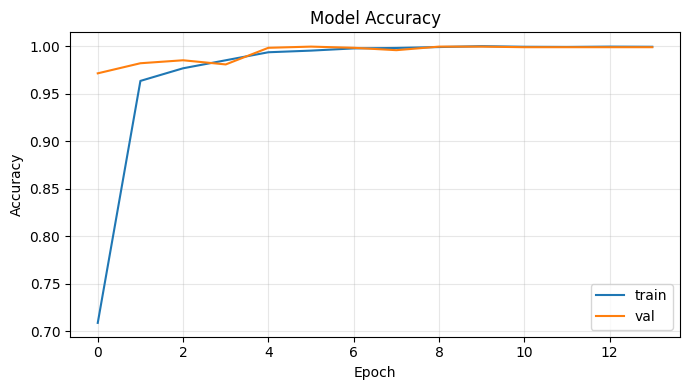

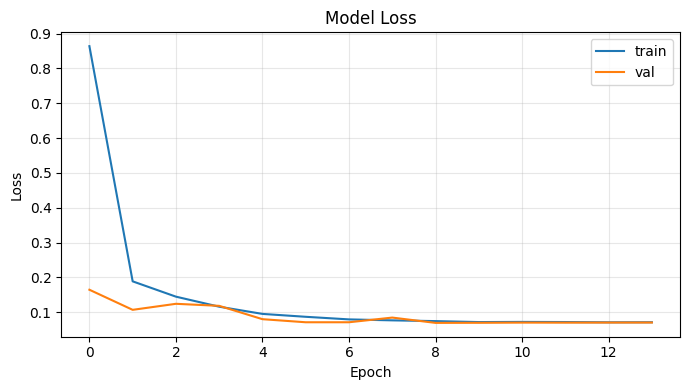


=== Test-set Evaluation (TransQ) ===
Accuracy          : 1.0000
F1 (macro)        : 1.0000
F1 (weighted)     : 1.0000
Precision (w)     : 1.0000
Recall (w)        : 1.0000
Cohen's kappa     : 1.0000
Log loss          : 0.0011
Brier (mean MSE)  : 0.000084
R² (proba)        : 0.9995
AS / HS / SC      : 1.0000 / 1.0000 / 0.0000
MSE (mean MSE)  : 0.000084
RMSE (mean RMSE)  : 0.009141
MAE (mean MAE)  : 0.000403

Critical class: Failure Stad 2 (index=4)
Recall critical   : 1.0000
FNR critical      : 0.0000

Classification report:
                  precision    recall  f1-score   support

       Very High     1.0000    1.0000    1.0000       400
            High     1.0000    1.0000    1.0000       400
High, frequently     1.0000    1.0000    1.0000       400
  Failure Stad 1     1.0000    1.0000    1.0000       400
  Failure Stad 2     1.0000    1.0000    1.0000       400

        accuracy                         1.0000      2000
       macro avg     1.0000    1.0000    1.0000      2000
   

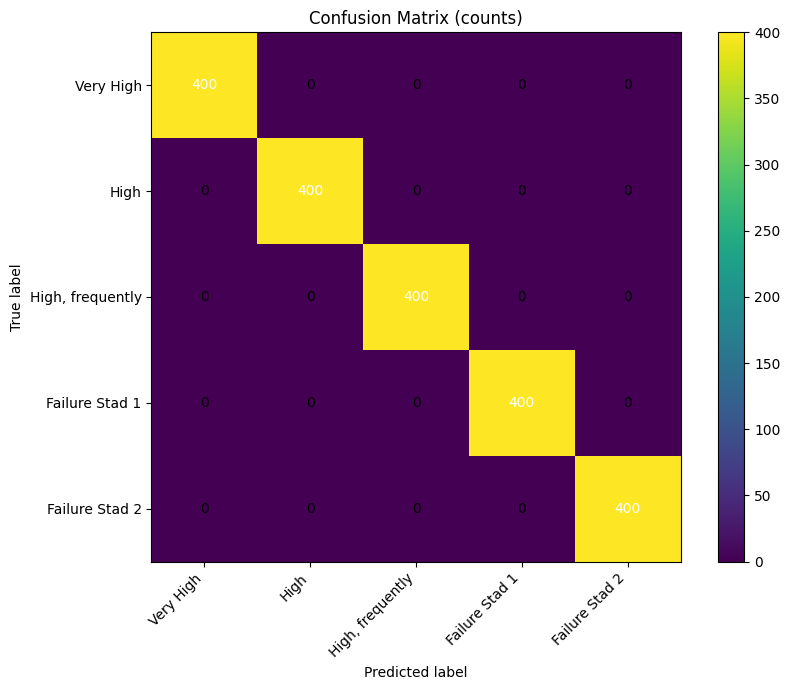

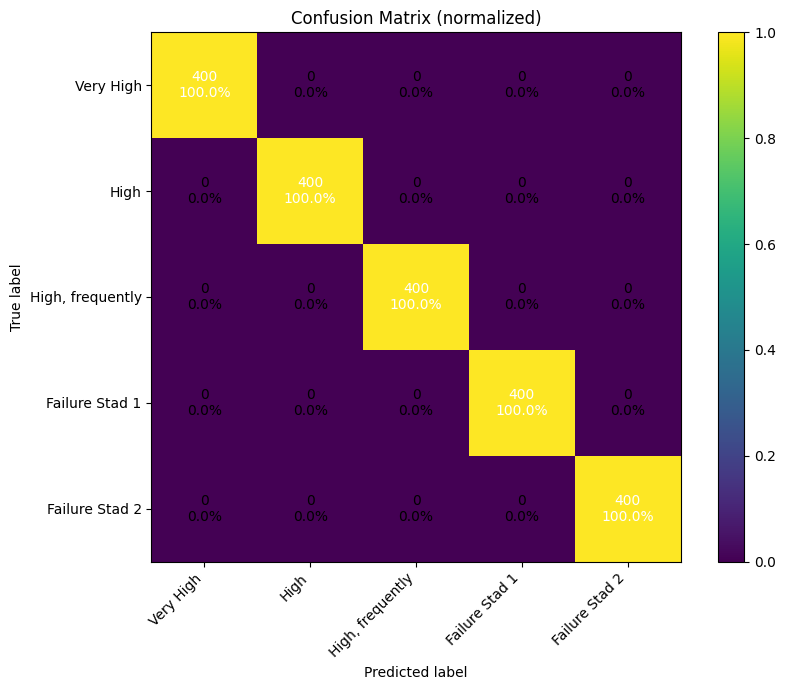


Per-class Sensitivity (SE) & Specificity (SP):
             Very High | SE=1.0000 | SP=1.0000
                  High | SE=1.0000 | SP=1.0000
      High, frequently | SE=1.0000 | SP=1.0000
        Failure Stad 1 | SE=1.0000 | SP=1.0000
        Failure Stad 2 | SE=1.0000 | SP=1.0000


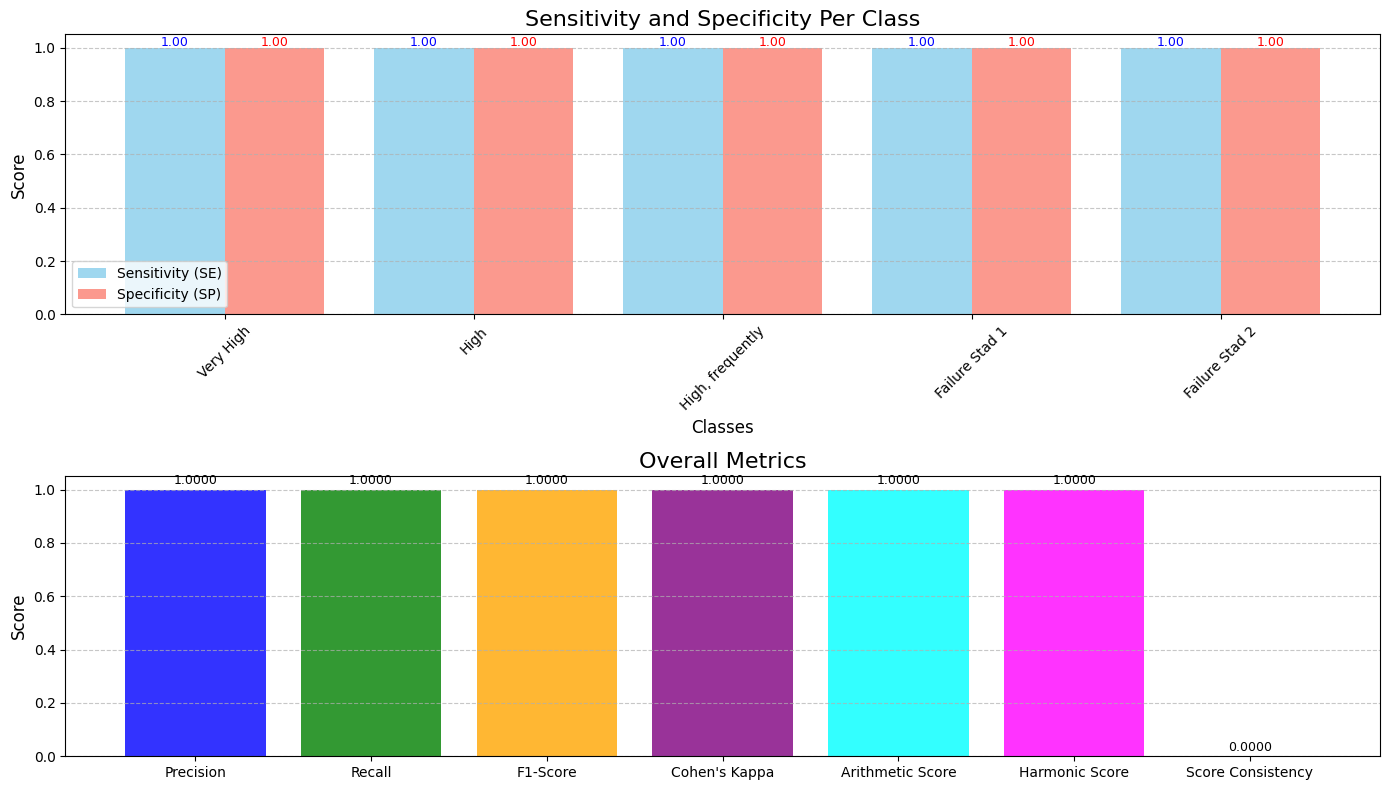

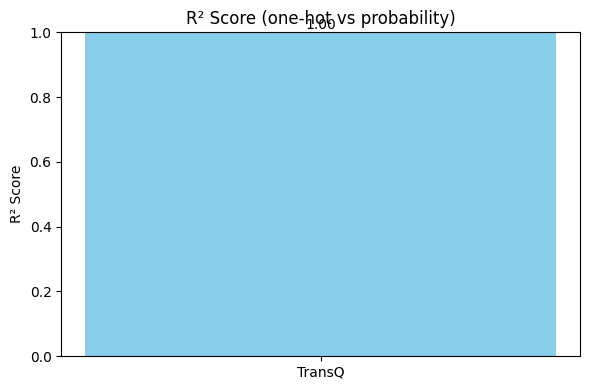

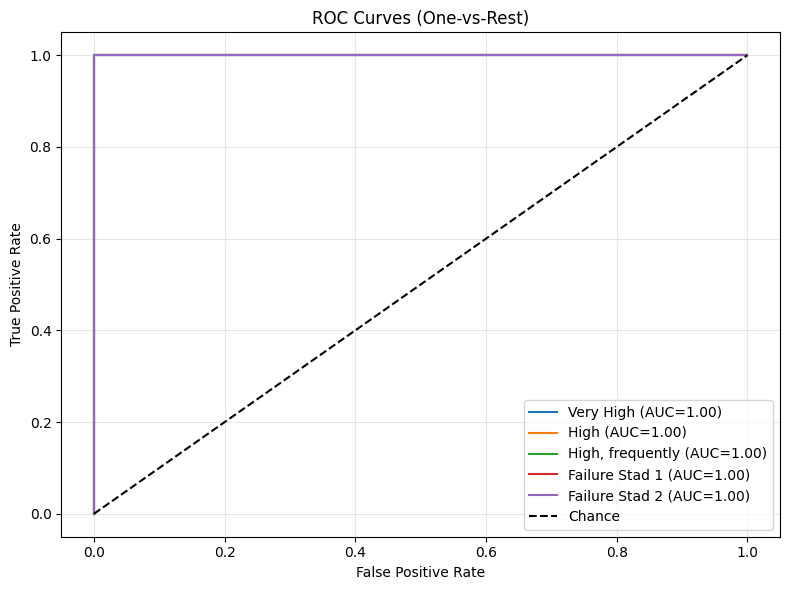

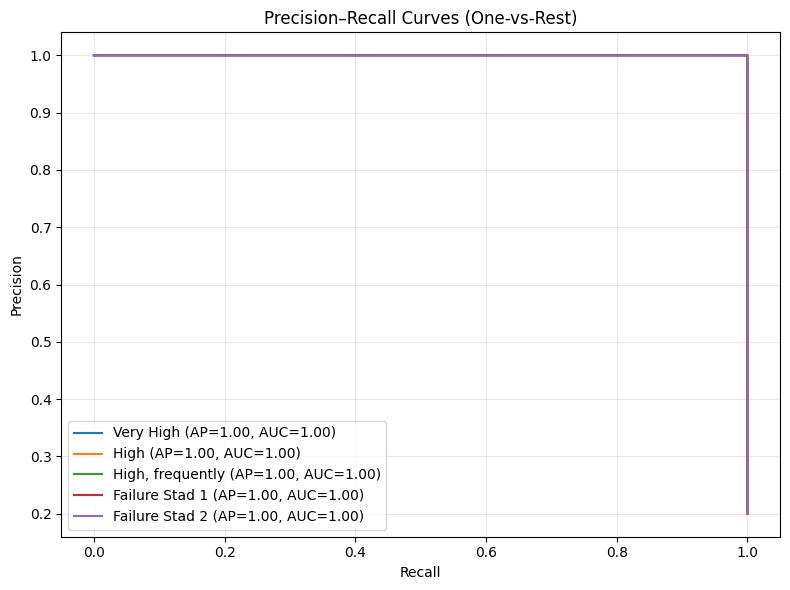


===== Fold 1/5 =====
acc=1.0000 | f1_macro=1.0000 | f1_weighted=1.0000 | logloss=0.0001 | brier=0.000003 | mse=0.000005 | rmse=0.002293 | mae=0.000054  

===== Fold 2/5 =====
acc=1.0000 | f1_macro=1.0000 | f1_weighted=1.0000 | logloss=0.0001 | brier=0.000003 | mse=0.000082 | rmse=0.009078 | mae=0.000136  

===== Fold 3/5 =====
acc=1.0000 | f1_macro=1.0000 | f1_weighted=1.0000 | logloss=0.0000 | brier=0.000000 | mse=0.000001 | rmse=0.000783 | mae=0.000013  

===== Fold 4/5 =====
acc=1.0000 | f1_macro=1.0000 | f1_weighted=1.0000 | logloss=0.0004 | brier=0.000032 | mse=0.000134 | rmse=0.011580 | mae=0.000319  

===== Fold 5/5 =====
acc=0.9992 | f1_macro=0.9992 | f1_weighted=0.9992 | logloss=0.0009 | brier=0.000098 | mse=0.000033 | rmse=0.005771 | mae=0.000274  

=== CV Summary ===
       acc: 0.9998 ± 0.0003
  f1_macro: 0.9998 ± 0.0003
f1_weighted: 0.9998 ± 0.0003
   logloss: 0.0003 ± 0.0003
     brier: 0.0000 ± 0.0000
       mse: 0.0001 ± 0.0001
      rmse: 0.0059 ± 0.0040
       mae: 0

C:\Users\user\AppData\Local\Temp\ipykernel_1732\910997888.py:144: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


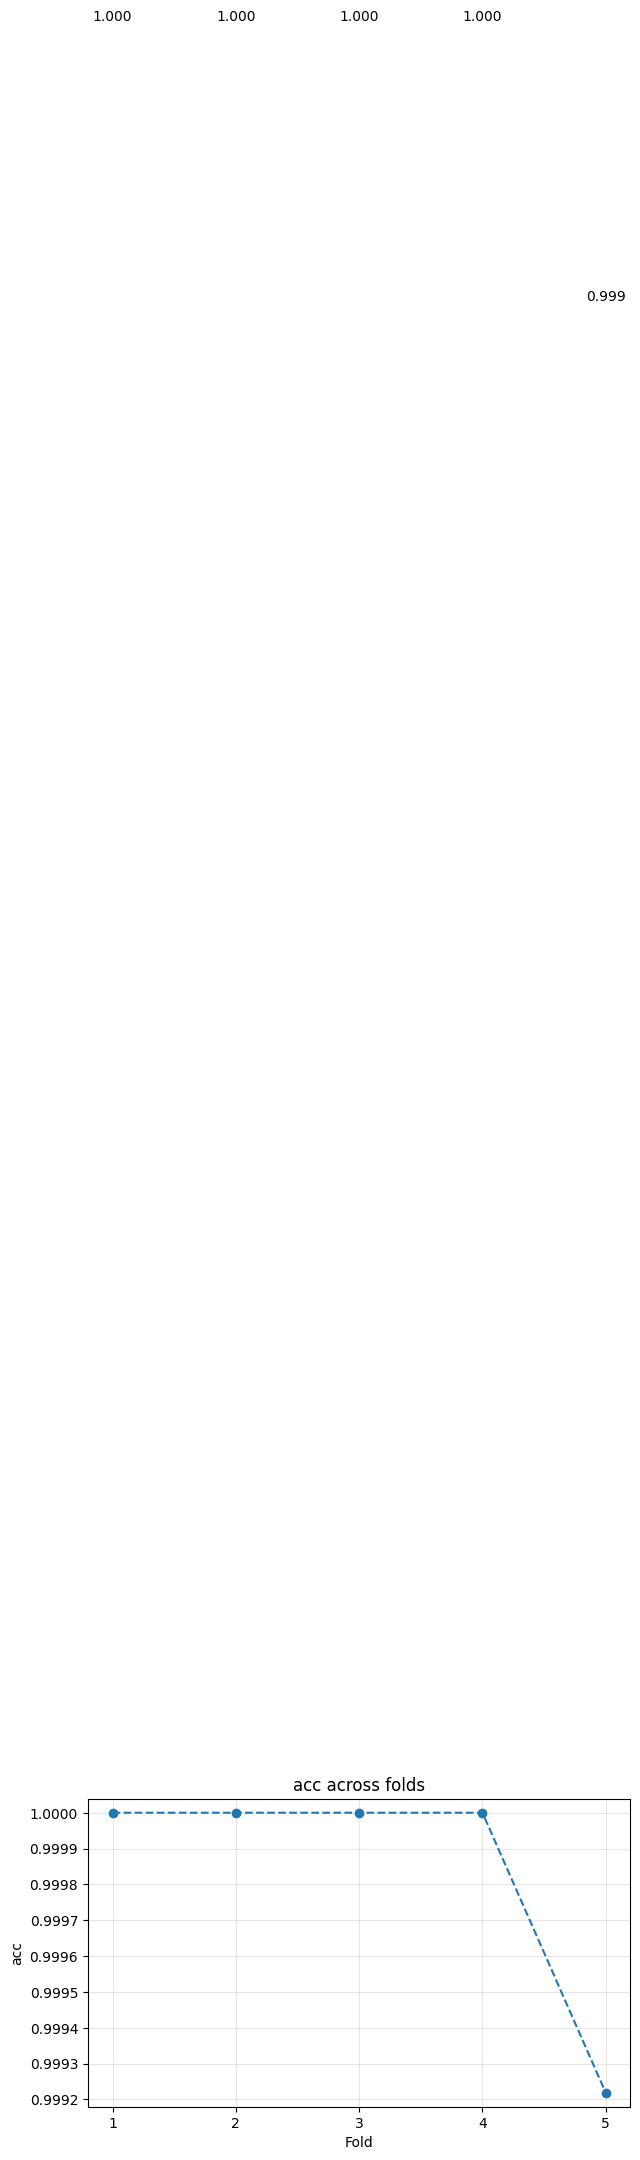

Saved: C:\Users\user\Documents\Imam_Sya_roni\Transformer1_model_new1.keras
Saved: C:\Users\user\Documents\Imam_Sya_roni\scaler_transq1.pkl
Saved: C:\Users\user\Documents\Imam_Sya_roni\label_encoder_transq1.pkl


In [2]:
#%%Cross-Validation

# =========================
# Extra helpers (AS/HS/SC + plots)
# =========================
def to_class_ids(y):
    """Accept one-hot or class-id labels -> class-id."""
    y = np.asarray(y)
    return y.argmax(axis=1) if y.ndim > 1 else y

def plot_history(history):
    # Accuracy
    plt.figure(figsize=(7, 4))
    plt.plot(history.history.get("accuracy", []), label="train")
    plt.plot(history.history.get("val_accuracy", []), label="val")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Loss
    plt.figure(figsize=(7, 4))
    plt.plot(history.history.get("loss", []), label="train")
    plt.plot(history.history.get("val_loss", []), label="val")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
def sensitivity_specificity_from_cm(cm):
    """
    Per-class Sensitivity (Recall/TPR) and Specificity (TNR).
    """
    cm = np.asarray(cm)
    K = cm.shape[0]
    se = np.zeros(K, dtype=float)
    sp = np.zeros(K, dtype=float)
    total = cm.sum()

    for i in range(K):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - (tp + fn + fp)
        se[i] = tp / (tp + fn + 1e-12)
        sp[i] = tn / (tn + fp + 1e-12)

    return se, sp

def plot_confusion_matrix(cm, class_names, normalize=True, title="Confusion Matrix"):
    cm = np.asarray(cm)
    if normalize:
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_vis = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            cm_vis = np.nan_to_num(cm_vis)
    else:
        cm_vis = cm

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_vis, interpolation="nearest")
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=title + (" (normalized)" if normalize else " (counts)")
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # annotate: count + %
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            if normalize:
                pct = cm_vis[i, j] * 100
                txt = f"{count}\n{pct:.1f}%"
                color = "white" if cm_vis[i, j] > 0.5 else "black"
            else:
                txt = f"{count}"
                color = "white" if cm_vis[i, j] > (cm_vis.max() / 2.0) else "black"

            ax.text(j, i, txt, ha="center", va="center", color=color)

    plt.tight_layout()
    plt.show()
    
def plot_roc_ovr(y_true_ids, y_prob, class_names):
    plt.figure(figsize=(8, 6))
    for i, name in enumerate(class_names):
        if np.sum(y_true_ids == i) == 0:
            continue
        fpr, tpr, _ = roc_curve((y_true_ids == i).astype(int), y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.title("ROC Curves (One-vs-Rest)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_pr_ovr(y_true_ids, y_prob, class_names):
    plt.figure(figsize=(8, 6))
    for i, name in enumerate(class_names):
        if np.sum(y_true_ids == i) == 0:
            continue
        p, r, _ = precision_recall_curve((y_true_ids == i).astype(int), y_prob[:, i])
        ap = average_precision_score((y_true_ids == i).astype(int), y_prob[:, i])
        pr_auc = auc(r, p)
        plt.plot(r, p, label=f"{name} (AP={ap:.2f}, AUC={pr_auc:.2f})")
    plt.title("Precision–Recall Curves (One-vs-Rest)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
def plot_cv_metric(results, key="acc"):
    vals = [r[key] for r in results]
    x = np.arange(1, len(vals) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(x, vals, marker="o", linestyle="--")
    plt.title(f"{key} across folds")
    plt.xlabel("Fold")
    plt.ylabel(key)
    plt.xticks(x)
    plt.grid(True, alpha=0.3)
    for i, v in enumerate(vals, start=1):
        plt.text(i, v + 0.005, f"{v:.3f}", ha="center")
    plt.tight_layout()
    plt.show()
    
def kfold_cv_classification(
    model_builder,
    X,
    y_onehot,
    n_splits=5,
    epochs=30,
    batch_size=32,
    callbacks=None,
    verbose_fit=0,
    random_state=42
):
    y_ids = np.argmax(y_onehot, axis=1)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    results = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_ids), start=1):
        print(f"\n===== Fold {fold}/{n_splits} =====")

        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y_onehot[tr_idx], y_onehot[va_idx]

        # scale inside fold (fit on train only)
        scaler_fold = StandardScaler()
        X_tr_sc = scaler_fold.fit_transform(X_tr)
        X_va_sc = scaler_fold.transform(X_va)

        tf.keras.backend.clear_session()
        model = model_builder()

        model.fit(
            X_tr_sc, y_tr,
            validation_data=(X_va_sc, y_va),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=verbose_fit
        )

        # --- Standard TEST metrics (for reporting)
        y_true_test = np.argmax(y_test_oh, axis=1)
        y_prob_test = model.predict(X_test_sc, verbose=0)
        
        # =========================
        # One-hot ground truth
        # =========================
        y_true_oh = np.eye(len(class_names))[y_true_test]

        y_prob = model.predict(X_va_sc, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_va, axis=1)

        acc = accuracy_score(y_true, y_pred)
        f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
        f1w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ll  = log_loss(y_true, y_prob, labels=list(range(y_prob.shape[1])))
        mse = float(np.mean((y_true_oh - y_prob_test) ** 2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(y_true_oh - y_prob_test)))

        y_true_oh = np.eye(y_prob.shape[1])[y_true]
        brier = float(np.mean((y_true_oh - y_prob) ** 2))

        print(f"acc={acc:.4f} | f1_macro={f1m:.4f} | f1_weighted={f1w:.4f} | logloss={ll:.4f} | brier={brier:.6f} | mse={mse:.6f} | rmse={rmse:.6f} | mae={mae:.6f}  ")
        results.append({"acc": acc, "f1_macro": f1m, "f1_weighted": f1w, "logloss": ll, "brier": brier, "mse": mse,"rmse": rmse, "mae": mae})

    # aggregate
    print("\n=== CV Summary ===")
    for k in results[0].keys():
        vals = np.array([r[k] for r in results], dtype=float)
        print(f"{k:>10s}: {vals.mean():.4f} ± {vals.std():.4f}")

    return results

def calculate_as_hs_sc(se, sp):
    """
    AS (Arithmetic Score), HS (Harmonic Score), SC (Score Consistency)
    based on per-class sensitivity (SE) and specificity (SP).
    """
    se = np.asarray(se, dtype=float)
    sp = np.asarray(sp, dtype=float)

    as_score = float(np.mean((se + sp) / 2.0))
    hs_score = float(np.mean(2.0 * se * sp / (se + sp + 1e-12)))
    sc_score = float(np.std(se + sp))  # lower = more consistent

    return as_score, hs_score, sc_score


def plot_se_sp_and_overall(
    class_names, se, sp,
    precision_weighted, recall_weighted, f1_weighted,
    kappa_score, arithmetic_score, harmonic_score, score_consistency
):
    # Plot Sensitivity, Specificity per Class + Overall metrics
    classes = class_names
    sensitivity = se
    specificity = sp

    plt.figure(figsize=(14, 8))

    # Subplot 1: Sensitivity and Specificity per class
    plt.subplot(2, 1, 1)
    x = np.arange(len(classes))
    bar1 = plt.bar(x - 0.2, sensitivity, width=0.4, label='Sensitivity (SE)', color='skyblue', alpha=0.8)
    bar2 = plt.bar(x + 0.2, specificity, width=0.4, label='Specificity (SP)', color='salmon', alpha=0.8)
    plt.xticks(x, classes, rotation=45)
    plt.ylim(0.0, 1.05)
    plt.title('Sensitivity and Specificity Per Class', fontsize=16)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Annotate Sensitivity and Specificity values
    for bar in bar1:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9, color='blue')
    for bar in bar2:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9, color='red')

    # Subplot 2: Overall metrics
    plt.subplot(2, 1, 2)
    metrics = ['Precision', 'Recall', 'F1-Score', "Cohen's Kappa", 'Arithmetic Score', 'Harmonic Score', 'Score Consistency']
    metric_values = [precision_weighted, recall_weighted, f1_weighted, kappa_score, arithmetic_score, harmonic_score, score_consistency]

    bar3 = plt.bar(metrics, metric_values, color=['blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'red'], alpha=0.8)
    plt.ylim(0, 1.05)
    plt.title('Overall Metrics', fontsize=16)
    plt.ylabel('Score', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Annotate Overall Metric values
    for bar in bar3:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9, color='black')

    plt.tight_layout()
    plt.show()


def plot_r2_bar(r2_value, model_name="TransQ"):
    r2_scores = {model_name: float(r2_value)}
    r2_values = list(r2_scores.values())

    plt.figure(figsize=(6, 4))
    plt.bar(r2_scores.keys(), r2_scores.values(), color='skyblue')
    plt.ylabel("R² Score")
    plt.title("R² Score (one-hot vs probability)")
    plt.ylim(0, 1)
    for i, v in enumerate(r2_values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
    plt.tight_layout()
    plt.show()

def evaluate_classifier(
    model,
    X_test_sc,
    y_test,             
    class_names,
    plot_roc_pr=True,
    critical_class_name="Failure Stad 2",
    model_name="TransQ"
):
    y_true_ids = to_class_ids(y_test)
    
    # --- Standard TEST metrics
    y_true_test = np.argmax(y_test_oh, axis=1)
    y_prob_test = model.predict(X_test_sc, verbose=0)
    
    # =========================
    # One-hot ground truth
    # =========================
    y_true_oh = np.eye(len(class_names))[y_true_test]

    mse = float(np.mean((y_true_oh - y_prob_test) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true_oh - y_prob_test)))

    # Predict probabilities
    y_prob = model.predict(X_test_sc, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # Basic metrics
    acc = accuracy_score(y_true_ids, y_pred)
    prec_w = precision_score(y_true_ids, y_pred, average="weighted", zero_division=0)
    rec_w  = recall_score(y_true_ids, y_pred, average="weighted", zero_division=0)
    f1_w   = f1_score(y_true_ids, y_pred, average="weighted", zero_division=0)
    f1_m   = f1_score(y_true_ids, y_pred, average="macro", zero_division=0)
    kappa  = cohen_kappa_score(y_true_ids, y_pred)

    # Probabilistic metrics
    ll = log_loss(y_true_ids, y_prob, labels=list(range(len(class_names))))
    y_true_oh = np.eye(len(class_names))[y_true_ids]
    brier = float(np.mean((y_true_oh - y_prob) ** 2))

    # R² between one-hot and prob
    r2 = float(r2_score(y_true_oh, y_prob, multioutput="variance_weighted"))

    # Confusion matrix + SE/SP
    cm = confusion_matrix(y_true_ids, y_pred, labels=np.arange(len(class_names)))
    se, sp = sensitivity_specificity_from_cm(cm)

    # AS/HS/SC
    as_score, hs_score, sc_score = calculate_as_hs_sc(se, sp)

    print("\n=== Test-set Evaluation (TransQ) ===")
    print(f"Accuracy          : {acc:.4f}")
    print(f"F1 (macro)        : {f1_m:.4f}")
    print(f"F1 (weighted)     : {f1_w:.4f}")
    print(f"Precision (w)     : {prec_w:.4f}")
    print(f"Recall (w)        : {rec_w:.4f}")
    print(f"Cohen's kappa     : {kappa:.4f}")
    print(f"Log loss          : {ll:.4f}")
    print(f"Brier (mean MSE)  : {brier:.6f}")
    print(f"R² (proba)        : {r2:.4f}")
    print(f"AS / HS / SC      : {as_score:.4f} / {hs_score:.4f} / {sc_score:.4f}")
    print(f"MSE (mean MSE)  : {mse:.6f}")
    print(f"RMSE (mean RMSE)  : {rmse:.6f}")
    print(f"MAE (mean MAE)  : {mae:.6f}")

    # Critical class recall/FNR
    if critical_class_name in class_names:
        cidx = class_names.index(critical_class_name)
        mask = (y_true_ids == cidx)
        if mask.sum() > 0:
            recall_c = float(np.mean(y_pred[mask] == cidx))
            fnr_c = float(1.0 - recall_c)
        else:
            recall_c, fnr_c = np.nan, np.nan
        print(f"\nCritical class: {critical_class_name} (index={cidx})")
        print(f"Recall critical   : {recall_c:.4f}")
        print(f"FNR critical      : {fnr_c:.4f}")
    else:
        cidx, recall_c, fnr_c = None, np.nan, np.nan

    print("\nClassification report:")
    print(classification_report(y_true_ids, y_pred, target_names=class_names, digits=4, zero_division=0))

    # Confusion matrices
    plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix")
    plot_confusion_matrix(cm, class_names, normalize=True,  title="Confusion Matrix")

    print("\nPer-class Sensitivity (SE) & Specificity (SP):")
    for i, name in enumerate(class_names):
        print(f"  {name:>20s} | SE={se[i]:.4f} | SP={sp[i]:.4f}")

    # Requested plots:
    plot_se_sp_and_overall(
        class_names=class_names,
        se=se, sp=sp,
        precision_weighted=prec_w,
        recall_weighted=rec_w,
        f1_weighted=f1_w,
        kappa_score=kappa,
        arithmetic_score=as_score,
        harmonic_score=hs_score,
        score_consistency=sc_score
    )
    plot_r2_bar(r2_value=r2, model_name=model_name)

    # ROC/PR (optional)
    if plot_roc_pr:
        plot_roc_ovr(y_true_ids, y_prob, class_names)
        plot_pr_ovr(y_true_ids, y_prob, class_names)

    return {
        "accuracy": acc,
        "f1_macro": f1_m,
        "f1_weighted": f1_w,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "kappa": kappa,
        "log_loss": ll,
        "brier": brier,
        "r2": r2,
        "as_score": as_score,
        "hs_score": hs_score,
        "sc_score": sc_score,
        "cm": cm,
        "se": se,
        "sp": sp,
        "critical_index": cidx,
        "recall_critical": recall_c,
        "fnr_critical": fnr_c
    }

plot_history(history)

class_names = ["Very High", "High", "High, frequently", "Failure Stad 1", "Failure Stad 2"]

metrics = evaluate_classifier(
    model=model,
    X_test_sc=X_test_sc,     # scaled
    y_test=y_test_oh,        # one-hot recommended
    class_names=class_names,
    plot_roc_pr=True,
    critical_class_name="Failure Stad 2",
    model_name="TransQ"
)

cv = kfold_cv_classification(
    model_builder=lambda: build_1d_transq_model(input_len=X_train_bal.shape[1], num_classes=len(class_names)),
    X=X_train_bal,
    y_onehot=y_train_oh,
    n_splits=5,
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose_fit=0
)
plot_cv_metric(cv, key="acc")

# -------------------------
# SAVE MODEL + ENCODER + SCALER
# -------------------------
import joblib


label_encoder = LabelEncoder()
label_encoder.fit(labels)

MODEL_PATH = r"C:\Users\user\Documents\Imam_Sya_roni\Transformer1_model_new1.keras"
ENC_PATH   = r"C:\Users\user\Documents\Imam_Sya_roni\label_encoder_transq1.pkl"
SCL_PATH   = r"C:\Users\user\Documents\Imam_Sya_roni\scaler_transq1.pkl"

# 1) Save model
model.save(MODEL_PATH)
print("Saved:", MODEL_PATH)

# 2) Save scaler
if "scaler" in globals() and scaler is not None:
    joblib.dump(scaler, SCL_PATH)
    print("Saved:", SCL_PATH)
else:
    print(" scaler not found -> scaler not saved.")

# 3) Save label_encoder ONLY if it exists
if "label_encoder" in globals() and label_encoder is not None:
    joblib.dump(label_encoder, ENC_PATH)
    print("Saved:", ENC_PATH)
else:
    # If encoder file already exists, do not overwrite; just notify
    if os.path.exists(ENC_PATH):
        print(" label_encoder not in memory. Existing encoder file kept:", ENC_PATH)
    else:
        print(" label_encoder not found and no existing encoder file. Encoder not saved.")

In [3]:
# =========================================================
# GPU CONFIG
# =========================================================
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for device in physical_devices:
        try:
            tf.config.experimental.set_memory_growth(device, True)
        except RuntimeError as e:
            print(f" {e}")
    print(f"GPU is available: {physical_devices}")
else:
    print("No GPU found. Using CPU.")

# Reproducibility (optional)
np.random.seed(42)
tf.random.set_seed(42)

# =========================================================
# USER CONFIG
# =========================================================
base_root  = r"C:\Users\user\Documents\Imam_Sya_roni\SWD_Machine_Learning\SWD_DB_ChamberMatched"
excel_path = r"C:\Users\user\Documents\Imam_Sya_roni\SWD_Machine_Learning\Laboratory Test Result.xlsx"
plate      = "Plate3"  # "Plate 1/3"

# Sensor sampling
dt_sec  = 20.0
dt_days = dt_sec / 86400.0

# Failure definition (Hz drop)
drop_pct         = 0.10      # 10% drop from baseline
baseline_minutes = 60.0
dwell_minutes    = 10.0

# Training
test_size   = 0.20
val_size    = 0.20   # val portion of TRAIN
random_state = 42
epochs      = 30
batch_size  = 64

# RCM
horizon_days      = 30.0
base_severity_S   = 9
failure_mode_name = f"Runway standing water sensor degradation ({plate})"

class_names = ["Very High", "High", "High, frequently", "Failure Stad 1", "Failure Stad 2"]

# =========================================================
# 1) DATA LOADER
# =========================================================
def infer_length_from_padding(X: np.ndarray, pad_value: float = 0.0) -> np.ndarray:
    mask = np.abs(X - pad_value) > 1e-12
    L = np.zeros((X.shape[0],), dtype=np.int32)
    for i in range(X.shape[0]):
        idx = np.where(mask[i])[0]
        L[i] = (idx[-1] + 1) if idx.size > 0 else 0
    return L

def load_multiple_mat_files(directory: str) -> Tuple[List[np.ndarray], List[Optional[np.ndarray]]]:
    X_list, L_list = [], []
    for filename in os.listdir(directory):
        if not filename.endswith(".mat"):
            continue
        file_path = os.path.join(directory, filename)
        try:
            mat = loadmat(file_path)
            if "durability" not in mat:
                continue
            X = np.asarray(mat["durability"], dtype=np.float32)
            if X.ndim != 2:
                continue

            L = None
            if "durability_len" in mat:
                Ltmp = np.asarray(mat["durability_len"], dtype=np.int32).reshape(-1, 1)
                if Ltmp.shape[0] == X.shape[0]:
                    L = Ltmp
            X_list.append(X)
            L_list.append(L)
        except Exception as e:
            print(f"Failed to load {filename}: {e}")
    return X_list, L_list

# =========================================================
# 2) TRANSQ + QUANTUM MODEL (model, with safe positional embedding)
# =========================================================
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
import pennylane as qml
from pennylane.qnn import KerasLayer

n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="tf", diff_method="backprop")
def quantum_circuit(inputs, weights):
    qml.templates.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.templates.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

weight_shapes = {"weights": (3, n_qubits)}
quantum_layer = KerasLayer(quantum_circuit, weight_shapes, output_dim=n_qubits)

def quantum_model_block(x_vec):
    x = layers.Dense(n_qubits)(x_vec)
    x = layers.LayerNormalization()(x)
    x = layers.Lambda(lambda t: np.pi * tf.tanh(t))(x)  # stabilize to [-pi, pi]
    q = quantum_layer(x)
    q = layers.Dense(64, activation="relu")(q)
    return q

def transformer_block(x, num_heads=4, key_dim=32, ff_dim=256, dropout=0.3, l2reg=1e-4):
    h = layers.LayerNormalization(epsilon=1e-6)(x)
    h = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(h, h)
    h = layers.Dropout(dropout)(h)
    x = layers.Add()([x, h])

    h = layers.LayerNormalization(epsilon=1e-6)(x)
    h = layers.Dense(ff_dim, activation="relu", kernel_regularizer=regularizers.l2(l2reg))(h)
    h = layers.Dropout(dropout)(h)
    h = layers.Dense(x.shape[-1], kernel_regularizer=regularizers.l2(l2reg))(h)
    x = layers.Add()([x, h])
    return x

class PositionalEmbedding1D(layers.Layer):
    def __init__(self, max_len: int, embed_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.embed_dim = embed_dim
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        # x: (batch, T, C)
        T = tf.shape(x)[1]
        positions = tf.range(start=0, limit=T, delta=1)          # (T,)
        pos = self.pos_emb(positions)                            # (T, C)
        pos = tf.expand_dims(pos, axis=0)                        # (1, T, C)
        return x + pos                                           # broadcast to (batch, T, C)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"max_len": self.max_len, "embed_dim": self.embed_dim})
        return cfg
def build_1d_transq_model(input_len=951, num_classes=5, patch_size=21, embed_dim=128):
    inp = layers.Input(shape=(input_len,), name="signal")
    x = layers.Reshape((input_len, 1))(inp)

    x = layers.Conv1D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="same")(x)
    x = PositionalEmbedding1D(max_len=2048, embed_dim=embed_dim, name="pos_emb")(x)

    x = transformer_block(x)
    x = transformer_block(x)

    cls = layers.GlobalAveragePooling1D()(x)
    cls = layers.Dense(64, activation="relu")(cls)

    q = quantum_model_block(inp)

    fused = layers.Concatenate()([cls, q])          # (batch, 128)
    gate  = layers.Dense(128, activation="sigmoid")(fused)
    fused = layers.Multiply()([fused, gate])

    h = layers.Dense(128, activation="relu")(fused)
    h = layers.Dropout(0.4)(h)
    out = layers.Dense(num_classes, activation="softmax")(h)

    model = models.Model(inp, out, name="TransQ_1D_Fused")
    model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# =========================================================
# 3) ALT EXTRACTION (Hz drop) FROM EXCEL
# =========================================================
def read_chamber_series(excel_path: str, sheet: str, plate: str) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_excel(excel_path, sheet_name=sheet, header=None)
    data = df.iloc[2:, :3].copy()
    data.columns = ["days", "single", "three"]
    data = data.dropna(subset=["days"])
    t_days = data["days"].astype(float).to_numpy()

    hz = data["single"].astype(float).to_numpy() if plate == "Plate1" else data["three"].astype(float).to_numpy()

    ok = ~np.isnan(t_days) & ~np.isnan(hz)
    return t_days[ok], hz[ok]

def extract_failure_time_days_from_time_axis(
    t_days: np.ndarray,
    hz: np.ndarray,
    test_duration_days: float,
    drop_pct: float,
    baseline_minutes: float,
    dwell_minutes: float,
) -> Tuple[float, int, float]:
    t = np.asarray(t_days, float)
    f = np.asarray(hz, float)
    if t.size == 0:
        return test_duration_days, 0, np.nan

    baseline_days = baseline_minutes / (24.0 * 60.0)
    base_idx = np.where(t <= (t[0] + baseline_days))[0]
    if base_idx.size == 0:
        base_idx = np.arange(min(5, t.size))
    f0 = float(np.mean(f[base_idx]))

    thr = f0 * (1.0 - float(drop_pct))
    dwell_days = dwell_minutes / (24.0 * 60.0)

    below = (f <= thr)
    i = 0
    while i < t.size:
        if below[i]:
            j = i
            while j < t.size and below[j]:
                j += 1
            dur = t[j-1] - t[i]
            if dur >= dwell_days:
                return float(min(t[i], test_duration_days)), 1, float(thr)
            i = j
        else:
            i += 1

    return float(test_duration_days), 0, float(thr)

def get_alt_from_excel(excel_path: str, plate: str) -> Dict[str, Dict[str, float]]:
    # Temperature (7 days)
    tT, hzT = read_chamber_series(excel_path, "Chamber Temperature Test", plate)
    t_fail_T, event_T, thr_T = extract_failure_time_days_from_time_axis(
        tT, hzT, 7.0, drop_pct, baseline_minutes, dwell_minutes
    )

    # Humidity (21 days)
    tH, hzH = read_chamber_series(excel_path, "Chamber Humidity Test", plate)
    t_fail_H, event_H, thr_H = extract_failure_time_days_from_time_axis(
        tH, hzH, 21.0, drop_pct, baseline_minutes, dwell_minutes
    )

    return {
        "temperature": {"t_fail_days": t_fail_T, "event": event_T, "thr_used": thr_T},
        "humidity":    {"t_fail_days": t_fail_H, "event": event_H, "thr_used": thr_H},
    }

# =========================================================
# 4) RELIABILITY + RCM (with censored-aware eta when beta fixed/estimated)
# =========================================================
@dataclass
class WeibullModel:
    beta: float
    eta: float

    def cdf(self, t: np.ndarray) -> np.ndarray:
        return weibull_min.cdf(t, c=self.beta, scale=self.eta)

    def p_fail_horizon(self, t_now: float, delta_t: float) -> float:
        return float(self.cdf(np.array([t_now + delta_t]))[0] - self.cdf(np.array([t_now]))[0])

def fit_beta_from_failures_only(fail_times: np.ndarray) -> float:
    # Weibull fit on failures only (no censoring), loc fixed to 0
    beta, loc, eta = weibull_min.fit(fail_times, floc=0)
    return float(beta)

def eta_mle_censored_beta_fixed(times: np.ndarray, events: np.ndarray, beta: float) -> float:
    # MLE eta with right-censoring when beta fixed:
    # eta^beta = sum(t_i^beta) / d, where d = number of failures
    times = np.asarray(times, float)
    events = np.asarray(events, int)
    d = int(np.sum(events == 1))
    if d <= 0:
        raise ValueError("No failures (d=0), cannot estimate eta with this formula.")
    sum_tbeta = float(np.sum(times ** beta))
    eta = (sum_tbeta / d) ** (1.0 / beta)
    return float(eta)

def build_weibull_from_alt(times: np.ndarray, events: np.ndarray, beta_assumed: float = 2.0) -> Tuple[WeibullModel, str]:
    times = np.asarray(times, float)
    events = np.asarray(events, int)

    fail_times = times[events == 1]
    if fail_times.size >= 2:
        beta = fit_beta_from_failures_only(fail_times)
        eta  = eta_mle_censored_beta_fixed(times, events, beta)
        return WeibullModel(beta=beta, eta=eta), "Weibull: beta from failures (>=2), eta censored-MLE."
    elif fail_times.size == 1:
        beta = float(beta_assumed)
        eta  = eta_mle_censored_beta_fixed(times, events, beta)  # uses censored info to enlarge eta
        return WeibullModel(beta=beta, eta=eta), "Weibull: beta assumed (=2.0), eta censored-MLE (uses humidity censored)."
    else:
        # no failure detected: fallback eta from max censor time
        beta = float(beta_assumed)
        eta  = float(np.max(times)) / (np.log(2.0) ** (1.0 / beta))  # median ~ max censor (rough)
        return WeibullModel(beta=beta, eta=eta), "Weibull: no failures, fallback eta from censor horizon."

def ai_predict_proba(model, X: np.ndarray) -> np.ndarray:
    return np.asarray(model.predict(X, verbose=0))

def detection_metrics_from_confusion(y_true: np.ndarray, y_pred: np.ndarray, positive_class: int) -> Dict[str, float]:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = np.sum((y_true == positive_class) & (y_pred == positive_class))
    fn = np.sum((y_true == positive_class) & (y_pred != positive_class))
    recall = tp / (tp + fn + 1e-12)
    fnr = 1.0 - recall
    return {"recall": float(recall), "fnr": float(fnr)}

@dataclass
class FMEAItem:
    failure_mode: str
    severity_S: int
    occurrence_O: int
    detection_D: int
    rpn: int = 0

    def compute_rpn(self) -> int:
        self.rpn = int(self.severity_S * self.occurrence_O * self.detection_D)
        return self.rpn

def map_probability_to_occurrence(prob: float) -> int:
    prob = float(np.clip(prob, 0.0, 1.0))
    # horizon probability bins
    if prob <= 0.001: return 1
    if prob <= 0.005: return 2
    if prob <= 0.01:  return 3
    if prob <= 0.03:  return 4
    if prob <= 0.05:  return 5
    if prob <= 0.10:  return 6
    if prob <= 0.20:  return 7
    if prob <= 0.40:  return 8
    if prob <= 0.70:  return 9
    return 10


def map_fnr_to_detection(fnr: float) -> int:
    fnr = float(np.clip(fnr, 0.0, 1.0))
    if fnr <= 0.01: return 1
    if fnr <= 0.03: return 2
    if fnr <= 0.05: return 3
    if fnr <= 0.08: return 4
    if fnr <= 0.12: return 5
    if fnr <= 0.18: return 6
    if fnr <= 0.25: return 7
    if fnr <= 0.35: return 8
    if fnr <= 0.50: return 9
    return 10

def ap_level_from_rpn(rpn: int) -> str:
    if rpn >= 300: return "AP1-Immediate"
    if rpn >= 180: return "AP2-Urgent"
    if rpn >= 90:  return "AP3-Plan"
    return "AP4-Monitor"

def fused_fail_prob_alt(weibull, t_now_alt_days: float, delta_alt_days: float,
                        p_critical: float, gamma: float = 2.0) -> float:
    """
    Δt-aware fusion:
    - Weibull gives baseline probability of failure in (t, t+Δt]
    - AI-agent p_critical inflates hazard by multiplier m = 1 + gamma*p_critical
    """
    p_base = float(weibull.p_fail_horizon(t_now=t_now_alt_days, delta_t=delta_alt_days))
    p_critical = float(np.clip(p_critical, 0.0, 1.0))
    m = 1.0 + gamma * p_critical

    # For small probabilities
    p = min(1.0, m * p_base)
    return p


def recommend_interval_days_field(weibull, t_now_field_days: float, p_critical: float,
                                 k_field_to_alt: float,
                                 target_p_fail: float = 0.10,
                                 max_days_field: float = 180.0,
                                 gamma: float = 2.0) -> float:
    """
    Find max FIELD interval such that fused_fail_prob_alt <= target_p_fail.
    Uses ALT-equivalent time via k scaling.
    """
    if max_days_field <= 0:
        return 0.0

    t_now_alt = k_field_to_alt * float(t_now_field_days)

    # check 1 day
    p1 = fused_fail_prob_alt(
        weibull, t_now_alt_days=t_now_alt,
        delta_alt_days=k_field_to_alt * 1.0,
        p_critical=p_critical, gamma=gamma
    )
    if p1 > target_p_fail:
        return 0.0

    lo, hi = 0.0, float(max_days_field)
    for _ in range(40):
        mid = (lo + hi) / 2.0
        p = fused_fail_prob_alt(
            weibull, t_now_alt_days=t_now_alt,
            delta_alt_days=k_field_to_alt * mid,
            p_critical=p_critical, gamma=gamma
        )
        if p <= target_p_fail:
            lo = mid
        else:
            hi = mid
    return float(lo)


def maintenance_policy(ap_level: str, recommended_interval_days: float) -> Dict[str, object]:
    # action from AP level
    if ap_level == "AP1-Immediate":
        return {"action": "Replace/Remove from service", "interval_days": 0}
    if ap_level == "AP2-Urgent":
        return {"action": "Inspect + Calibrate + Reduce interval", "interval_days": int(np.ceil(recommended_interval_days))}
    if ap_level == "AP3-Plan":
        return {"action": "Scheduled inspection", "interval_days": int(np.ceil(recommended_interval_days))}
    return {"action": "Monitor", "interval_days": int(np.ceil(recommended_interval_days))}

def estimate_k_from_survival(weibull, t_field_days: float, S_target: float = 0.90) -> float:
    """
    Kalibrasi acceleration factor k dari fakta 'sensor survive sampai t_field_days'.
    Asumsi: pada umur sekarang, survival di skala ALT-equivalent ~ S_target.
    S(t) = exp(-(t/eta)^beta) = S_target
    => t_alt = eta * (-ln(S_target))^(1/beta)
    => k = t_alt / t_field_days
    """
    t_field_days = float(t_field_days)
    if t_field_days <= 0:
        raise ValueError("t_field_days must be > 0")

    beta = float(weibull.beta)
    eta  = float(weibull.eta)

    if not (0.0 < S_target < 1.0):
        raise ValueError("S_target must be between 0 and 1 (exclusive)")

    t_alt = eta * ((-np.log(S_target)) ** (1.0 / beta))
    k = t_alt / t_field_days
    # guard (avoid zero)
    return float(max(k, 1e-12))


@dataclass
class FrameworkConfig:
    horizon_days: float
    critical_class_index: int
    failure_mode_name: str

class AIinformedRCMFramework:
    def __init__(self, config: FrameworkConfig, weibull: WeibullModel):
        self.config = config
        self.weibull = weibull

    def run_decision(
        self,
        model,
        X: np.ndarray,
        y_true_class: np.ndarray,
        base_severity_S: int,
        simulate_field_2y: bool = True,
        t_now_field_days: float = 365.0 * 2,
        S_target: float = 0.90,
        target_p_fail: float = 0.10,
        max_days_field: float = 180.0,
        gamma: float = 2.0,
        D_fixed: int = 1,
    ):
        proba = ai_predict_proba(model, X)
        y_pred = np.argmax(proba, axis=1)

        # Detection (deployment-safe)
        if y_true_class is None:
            det = {"recall": np.nan, "fnr": np.nan}
            D = int(D_fixed)
        else:
            det = detection_metrics_from_confusion(y_true_class, y_pred, self.config.critical_class_index)
            D = map_fnr_to_detection(det["fnr"])

        p_critical = float(np.mean(proba[:, self.config.critical_class_index]))

        # ---- Field simulation (2 years) ----
        if simulate_field_2y:
            k = estimate_k_from_survival(self.weibull, t_field_days=t_now_field_days, S_target=S_target)
            t_now_alt = k * float(t_now_field_days)
            horizon_alt = k * float(self.config.horizon_days)

            p_fail_base = float(self.weibull.p_fail_horizon(t_now=t_now_alt, delta_t=horizon_alt))

            recommended_field = recommend_interval_days_field(
                weibull=self.weibull,
                t_now_field_days=float(t_now_field_days),
                p_critical=p_critical,
                k_field_to_alt=k,
                target_p_fail=target_p_fail,
                max_days_field=max_days_field,
                gamma=gamma
            )
        else:
            # ALT-time direct mode
            k = np.nan
            t_now_alt = np.nan
            horizon_alt = np.nan
            p_fail_base = float(self.weibull.p_fail_horizon(t_now=0.0, delta_t=self.config.horizon_days))
            recommended_field = np.nan

        # Δt-aware fused risk
        if simulate_field_2y:
            p_fail = fused_fail_prob_alt(
                self.weibull,
                t_now_alt_days=t_now_alt,
                delta_alt_days=horizon_alt,
                p_critical=p_critical,
                gamma=gamma
            )
        else:
            p_fail = 1.0 - (1.0 - p_fail_base) * (1.0 - p_critical)  # legacy

        O = map_probability_to_occurrence(p_fail)

        fmea = FMEAItem(
            failure_mode=self.config.failure_mode_name,
            severity_S=int(base_severity_S),
            occurrence_O=int(O),
            detection_D=int(D)
        )
        rpn = fmea.compute_rpn()
        ap = ap_level_from_rpn(rpn)

        plan = maintenance_policy(ap, recommended_interval_days=recommended_field if simulate_field_2y else self.config.horizon_days)

        debug = {
            "simulate_field_2y": bool(simulate_field_2y),
            "S_target": float(S_target),
            "t_now_field_days": float(t_now_field_days) if simulate_field_2y else np.nan,
            "k_field_to_alt": float(k) if simulate_field_2y else np.nan,
            "t_now_alt_equiv_days": float(t_now_alt) if simulate_field_2y else np.nan,
            "horizon_alt_equiv_days": float(horizon_alt) if simulate_field_2y else np.nan,
            "p_fail_base_weibull": float(p_fail_base),
            "p_critical_ai": float(p_critical),
            "gamma": float(gamma),
            "p_fail_fused": float(p_fail),
            "occurrence_O": int(O),
            "detection_D": int(D),
            "rpn": float(rpn),
            "ap_level": ap,
            "recall_critical": float(det["recall"]) if det["recall"] is not None else np.nan,
            "fnr_critical": float(det["fnr"]) if det["fnr"] is not None else np.nan,
            "recommended_interval_days_field@target_risk": float(recommended_field) if simulate_field_2y else np.nan,
            "target_p_fail": float(target_p_fail),
            "max_days_field_search": float(max_days_field),
        }
        return fmea, plan, debug

# =========================================================
# 5) AI-AGENT (Rule-based Orchestrator)
# =========================================================

@dataclass
class AgentConfig:
    plate: str
    horizon_days: float = 30.0
    base_severity_S: int = 9
    S_target: float = 0.90
    t_now_field_days: float = 365.0 * 2
    target_p_fail: float = 0.10
    max_days_field: float = 180.0
    gamma: float = 2.0
    critical_class_name: str = "Failure Stad 2"
    export_dir: Optional[str] = None
    run_sensitivity: bool = True
    alphas: Tuple[float, ...] = (0.10, 0.05, 0.02, 0.01)
    gammas: Tuple[float, ...] = (0.0, 1.0, 2.0, 3.0)

@dataclass
class AgentState:
    class_names: List[str]
    critical_idx: int
    model: Optional[tf.keras.Model] = None
    history: Optional[object] = None
    scaler: Optional[StandardScaler] = None
    test_metrics: Optional[dict] = None
    D_fixed: int = 5
    alt: Optional[dict] = None
    weibull: Optional[WeibullModel] = None
    weibull_note: str = ""
    rcm_fmea: Optional[FMEAItem] = None
    rcm_plan: Optional[dict] = None
    rcm_debug: Optional[dict] = None
    sensitivity_table: Optional[pd.DataFrame] = None

class SWDAIAgent:
    """
    Local AI-agent (rule-based) to run:
    Train -> Evaluate -> Compute D_fixed -> ALT -> Weibull -> RCM -> Sensitivity
    """
    def __init__(
        self,
        cfg: AgentConfig,
        base_root: str,
        excel_path: str,
        directories: Dict[str, str],
        label_encoder: LabelEncoder
    ):
        self.cfg = cfg
        self.base_root = base_root
        self.excel_path = excel_path
        self.directories = directories
        self.le = label_encoder

        class_names = list(self.le.classes_)
        if cfg.critical_class_name not in class_names:
            raise ValueError(f"critical_class_name='{cfg.critical_class_name}' not found in classes_: {class_names}")

        self.state = AgentState(
            class_names=class_names,
            critical_idx=int(self.le.transform([cfg.critical_class_name])[0])
        )

    # -------------------------
    # Step A: Train model
    # -------------------------
    def train(
        self,
        X_train_bal_sc: np.ndarray,
        y_train_oh: np.ndarray,
        X_val_sc: np.ndarray,
        y_val_oh: np.ndarray,
        epochs: int,
        batch_size: int,
        callbacks: list
    ):
        model = build_1d_transq_model(input_len=X_train_bal_sc.shape[1], num_classes=y_train_oh.shape[1])
        hist = model.fit(
            X_train_bal_sc, y_train_oh,
            validation_data=(X_val_sc, y_val_oh),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=callbacks
        )
        self.state.model = model
        self.state.history = hist
        return model, hist

    # -------------------------
    # Step B: Evaluate and derive D_fixed from VAL
    # -------------------------
    def evaluate_and_set_D_fixed(
    self,
        X_val_sc: np.ndarray,
        y_val_idx: np.ndarray,
        X_test_sc: np.ndarray,
        y_test_oh: np.ndarray
    ):
        assert self.state.model is not None, "Model not trained yet."

        # --- D_fixed from VAL (offline monitoring)
        y_prob_val = self.state.model.predict(X_val_sc, verbose=0)
        y_pred_val = np.argmax(y_prob_val, axis=1)
        det_val = detection_metrics_from_confusion(
            y_true=y_val_idx,
            y_pred=y_pred_val,
            positive_class=self.state.critical_idx
        )
        self.state.D_fixed = map_fnr_to_detection(det_val["fnr"])
    
        # --- Evaluate test_loss and test_acc using Keras evaluate
        test_loss, test_acc = self.state.model.evaluate(X_test_sc, y_test_oh, verbose=0)
    
        # --- Standard TEST metrics
        y_true_test = np.argmax(y_test_oh, axis=1)
        y_prob_test = self.state.model.predict(X_test_sc, verbose=0)
        y_pred_test = np.argmax(y_prob_test, axis=1)
        
        # =========================
        # One-hot ground truth
        # =========================
        y_true_oh = np.eye(len(class_names))[y_true_test]
        
        # =========================
        # Probabilistic error metrics
        # =========================
        mse = float(np.mean((y_true_oh - y_prob_test) ** 2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(y_true_oh - y_prob_test)))
    
        acc = accuracy_score(y_true_test, y_pred_test)
        f1m = f1_score(y_true_test, y_pred_test, average="macro", zero_division=0)
        f1w = f1_score(y_true_test, y_pred_test, average="weighted", zero_division=0)
        ll  = log_loss(y_true_test, y_prob_test, labels=list(range(len(self.state.class_names))))
        y_true_oh = np.eye(len(self.state.class_names))[y_true_test]
        brier = float(np.mean((y_true_oh - y_prob_test) ** 2))
    
        # critical recall/FNR on TEST
        mask = (y_true_test == self.state.critical_idx)
        recall_c = float(np.mean(y_pred_test[mask] == self.state.critical_idx)) if mask.sum() else np.nan
        fnr_c = float(1.0 - recall_c) if mask.sum() else np.nan
    
        self.state.test_metrics = {
            # fields
            "test_loss": float(test_loss),
            "test_acc_eval": float(test_acc),
    
            # probabilistic errors
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
        
            # existing metrics
            "accuracy": float(acc),
            "f1_macro": float(f1m),
            "f1_weighted": float(f1w),
            "log_loss": float(ll),
            "brier": float(brier),
    
            "recall_critical_test": float(recall_c),
            "fnr_critical_test": float(fnr_c),
    
            "D_fixed_from_val": int(self.state.D_fixed),
            "val_recall_critical": float(det_val["recall"]),
            "val_fnr_critical": float(det_val["fnr"]),
        }
    
        # --- Agent warnings (rule-based)
        if acc > 0.999:
            print("Agent note: Test accuracy is extremely high. Consider file/device-level group split to rule out leakage.")
    
        return self.state.test_metrics

    # -------------------------
    # Step C: ALT -> Weibull
    # -------------------------
    def alt_and_weibull(self):
        alt = get_alt_from_excel(self.excel_path, plate=self.cfg.plate)
        self.state.alt = alt

        # sanity check: very early failure
        if alt["temperature"]["event"] == 1 and alt["temperature"]["t_fail_days"] < 0.05:
            print("Agent warning: Temperature failure time is extremely early (<0.05 days). "
                  "Consider burn-in exclusion window or stronger dwell constraint to avoid transient-trigger failure.")

        times = np.array([alt["temperature"]["t_fail_days"], alt["humidity"]["t_fail_days"]], dtype=float)
        events = np.array([alt["temperature"]["event"],      alt["humidity"]["event"]], dtype=int)

        weibull, note = build_weibull_from_alt(times, events, beta_assumed=2.0)
        self.state.weibull = weibull
        self.state.weibull_note = note
        return alt, weibull, note

    # -------------------------
    # Step D: RCM decision
    # -------------------------
    def rcm_decision(self, X_for_rcm_sc: np.ndarray):
        assert self.state.model is not None
        assert self.state.weibull is not None

        cfg = FrameworkConfig(
            horizon_days=self.cfg.horizon_days,
            critical_class_index=self.state.critical_idx,
            failure_mode_name=f"Runway standing water sensor degradation ({self.cfg.plate})"
        )
        fw = AIinformedRCMFramework(cfg, self.state.weibull)

        fmea, plan, debug = fw.run_decision(
            model=self.state.model,
            X=X_for_rcm_sc,
            y_true_class=None,  # deployment-safe
            base_severity_S=self.cfg.base_severity_S,
            simulate_field_2y=True,
            t_now_field_days=self.cfg.t_now_field_days,
            S_target=self.cfg.S_target,
            target_p_fail=self.cfg.target_p_fail,
            max_days_field=self.cfg.max_days_field,
            gamma=self.cfg.gamma,
            D_fixed=self.state.D_fixed
        )

        self.state.rcm_fmea = fmea
        self.state.rcm_plan = plan
        self.state.rcm_debug = debug
        return fmea, plan, debug

    # -------------------------
    # Step E: Sensitivity analysis (alpha & gamma)
    # -------------------------
    def sensitivity(self, X_for_rcm_sc: np.ndarray):
        assert self.state.model is not None
        assert self.state.weibull is not None

        # compute p_critical on this input once
        proba = ai_predict_proba(self.state.model, X_for_rcm_sc)
        p_critical = float(np.mean(proba[:, self.state.critical_idx]))

        k = estimate_k_from_survival(self.state.weibull, t_field_days=self.cfg.t_now_field_days, S_target=self.cfg.S_target)

        rows = []
        for a in self.cfg.alphas:
            for g in self.cfg.gammas:
                interval = recommend_interval_days_field(
                    weibull=self.state.weibull,
                    t_now_field_days=self.cfg.t_now_field_days,
                    p_critical=p_critical,
                    k_field_to_alt=k,
                    target_p_fail=a,
                    max_days_field=self.cfg.max_days_field,
                    gamma=g
                )
                rows.append({
                    "plate": self.cfg.plate,
                    "S_target": self.cfg.S_target,
                    "alpha": a,
                    "gamma": g,
                    "p_critical": p_critical,
                    "k_field_to_alt": k,
                    "interval_days": float(interval)
                })

        df = pd.DataFrame(rows)
        self.state.sensitivity_table = df
        return df

    # -------------------------
    # Step F: Export summary
    # -------------------------
    def export(self):
        if not self.cfg.export_dir:
            return
        os.makedirs(self.cfg.export_dir, exist_ok=True)

        # 1) metrics
        if self.state.test_metrics is not None:
            pd.DataFrame([self.state.test_metrics]).to_csv(os.path.join(self.cfg.export_dir, "metrics_test.csv"), index=False)

        # 2) ALT + Weibull
        if self.state.alt is not None and self.state.weibull is not None:
            alt_flat = {
                "plate": self.cfg.plate,
                "temp_t_fail_days": self.state.alt["temperature"]["t_fail_days"],
                "temp_event": self.state.alt["temperature"]["event"],
                "temp_thr": self.state.alt["temperature"]["thr_used"],
                "hum_t_fail_days": self.state.alt["humidity"]["t_fail_days"],
                "hum_event": self.state.alt["humidity"]["event"],
                "hum_thr": self.state.alt["humidity"]["thr_used"],
                "weibull_beta": self.state.weibull.beta,
                "weibull_eta": self.state.weibull.eta,
                "weibull_note": self.state.weibull_note
            }
            pd.DataFrame([alt_flat]).to_csv(os.path.join(self.cfg.export_dir, "alt_weibull.csv"), index=False)

        # 3) RCM
        if self.state.rcm_fmea is not None and self.state.rcm_plan is not None and self.state.rcm_debug is not None:
            rcm_flat = {
                "plate": self.cfg.plate,
                "failure_mode": self.state.rcm_fmea.failure_mode,
                "S": self.state.rcm_fmea.severity_S,
                "O": self.state.rcm_fmea.occurrence_O,
                "D": self.state.rcm_fmea.detection_D,
                "RPN": self.state.rcm_fmea.rpn,
                "AP": self.state.rcm_debug.get("ap_level", ""),
                "action": self.state.rcm_plan.get("action", ""),
                "interval_days": self.state.rcm_plan.get("interval_days", np.nan),
                "p_fail_base": self.state.rcm_debug.get("p_fail_base_weibull", np.nan),
                "p_critical": self.state.rcm_debug.get("p_critical_ai", np.nan),
                "p_fail_fused": self.state.rcm_debug.get("p_fail_fused", np.nan),
            }
            pd.DataFrame([rcm_flat]).to_csv(os.path.join(self.cfg.export_dir, "rcm_output.csv"), index=False)

        # 4) sensitivity
        if self.state.sensitivity_table is not None:
            self.state.sensitivity_table.to_csv(os.path.join(self.cfg.export_dir, "sensitivity_alpha_gamma.csv"), index=False)

        print(f" Agent exported results to: {self.cfg.export_dir}")

    # -------------------------
    # One-call runner
    # -------------------------
    def run_all(
        self,
        X_train_bal_sc, y_train_oh,
        X_val_sc, y_val_oh, y_val_idx,
        X_test_sc, y_test_oh,
        epochs, batch_size, callbacks,
        X_for_rcm_sc
    ):
        print("\n [Agent] Training model ...")
        self.train(X_train_bal_sc, y_train_oh, X_val_sc, y_val_oh, epochs, batch_size, callbacks)

        print("\n [Agent] Evaluating & setting D_fixed from validation ...")
        self.evaluate_and_set_D_fixed(X_val_sc, y_val_idx, X_test_sc, y_test_oh)
        print("D_fixed:", self.state.D_fixed, "| class:", self.state.class_names[self.state.critical_idx])

        print(f" [Agent] test_acc_eval={self.state.test_metrics['test_acc_eval']:.4f} | "
      f"test_loss={self.state.test_metrics['test_loss']:.4f}")

        print("\n [Agent] Extract ALT & fit Weibull ...")
        alt, weibull, note = self.alt_and_weibull()
        print("ALT Temperature:", alt["temperature"])
        print("ALT Humidity   :", alt["humidity"])
        print("Weibull:", note, f"beta={weibull.beta:.4f}, eta={weibull.eta:.4f} days")

        print("\n [Agent] Running AI-informed RCM decision ...")
        fmea, plan, debug = self.rcm_decision(X_for_rcm_sc)
        print("FMEA:", fmea)
        print("Plan:", plan)
        print("Debug(p_fail_fused):", debug.get("p_fail_fused"))

        if self.cfg.run_sensitivity:
            print("\n [Agent] Sensitivity (alpha, gamma) ...")
            df = self.sensitivity(X_for_rcm_sc)
            print(df.pivot_table(index="alpha", columns="gamma", values="interval_days", aggfunc="mean"))

        self.export()
        return self.state

# =========================================================
# MAIN
# =========================================================
if __name__ == "__main__":

    # ---- directories ----
    plate_root = os.path.join(base_root, plate)
    directories = {
        "Very High": os.path.join(plate_root, "VeryHigh"),
        "High": os.path.join(plate_root, "High"),
        "High, frequently": os.path.join(plate_root, "High,Frequently"),
        "Failure Stad 1": os.path.join(plate_root, "Failure1"),
        "Failure Stad 2": os.path.join(plate_root, "Failure2"),
    }
    for k, p in directories.items():
        if not os.path.isdir(p):
            raise FileNotFoundError(f"Folder not found for '{k}': {p}")

    # ---- load all ----
    X_chunks, L_chunks, labels = [], [], []
    for label, dirpath in directories.items():
        X_list, L_list = load_multiple_mat_files(dirpath)
        if not X_list:
            continue

        X_cat = np.vstack(X_list).astype(np.float32)
        X_chunks.append(X_cat)
        labels.extend([label] * X_cat.shape[0])

        L_rows = []
        for Xi, Li in zip(X_list, L_list):
            if Li is not None:
                L_rows.append(Li.reshape(-1, 1))
            else:
                L_rows.append(infer_length_from_padding(Xi, pad_value=0.0).reshape(-1, 1))
        L_cat = np.vstack(L_rows).astype(np.int32)
        L_chunks.append(L_cat)

    X_full = np.concatenate(X_chunks, axis=0)
    L_full = np.concatenate(L_chunks, axis=0).reshape(-1)  # counts
    labels = np.array(labels)

    print(" Data shape:", X_full.shape)
    print(" Class distribution:", Counter(labels))

    # ---- encode labels ----
    le = LabelEncoder()
    y_full = le.fit_transform(labels)
    num_classes = len(directories)
    print(" Label mapping:", {cls: int(i) for i, cls in enumerate(le.classes_)})

    critical_idx = int(le.transform(["Failure Stad 2"])[0])
    print(" Critical class index:", critical_idx)

    # ---- split test ----
    X_train_all, X_test, y_train_all, y_test_idx, L_train_all, L_test = train_test_split(
        X_full, y_full, L_full,
        test_size=test_size, random_state=random_state, stratify=y_full
    )

    # ---- split val from train (NATURAL, no balancing) ----
    X_train_raw, X_val, y_train_raw, y_val_idx, L_train, L_val = train_test_split(
        X_train_all, y_train_all, L_train_all,
        test_size=val_size, random_state=random_state, stratify=y_train_all
    )

    print("Train(raw) distribution:", Counter(y_train_raw))
    print("Val(natural) distribution:", Counter(y_val_idx))
    print("Test(natural) distribution:", Counter(y_test_idx))

    # ---- undersample TRAIN ONLY ----
    rus = RandomUnderSampler(random_state=random_state)
    X_train_bal, y_train_bal = rus.fit_resample(X_train_raw, y_train_raw)
    print("Train(balanced) distribution:", Counter(y_train_bal))

    # ---- one-hot ----
    y_train_oh = to_categorical(y_train_bal, num_classes=num_classes)
    y_val_oh   = to_categorical(y_val_idx, num_classes=num_classes)
    y_test_oh  = to_categorical(y_test_idx, num_classes=num_classes)

    # ---- scale (fit on balanced train) ----
    scaler = StandardScaler()
    X_train_bal = scaler.fit_transform(X_train_bal)
    X_val_sc    = scaler.transform(X_val)
    X_test_sc   = scaler.transform(X_test)

    # ---- build model (FIXED: use input_len, not input_dim) ----
    model = build_1d_transq_model(input_len=X_train_bal.shape[1], num_classes=num_classes)
    model.summary()

    # Callbacks to reduce overfit
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ]

    # ---- agent config ----
    agent_cfg = AgentConfig(
        plate=plate,
        horizon_days=horizon_days,
        base_severity_S=base_severity_S,
        S_target=0.90,
        t_now_field_days=365*2,
        target_p_fail=0.10,
        max_days_field=180.0,
        gamma=2.0,
        critical_class_name="Failure Stad 2",
        export_dir=r"C:\Users\user\Documents\Imam_Sya_roni\SWD_Machine_Learning\agent_outputs",
        run_sensitivity=True
    )

    agent = SWDAIAgent(
        cfg=agent_cfg,
        base_root=base_root,
        excel_path=excel_path,
        directories=directories,
        label_encoder=le
    )

    # run all
    state = agent.run_all(
        X_train_bal_sc=X_train_bal, y_train_oh=y_train_oh,
        X_val_sc=X_val_sc, y_val_oh=y_val_oh, y_val_idx=y_val_idx,
        X_test_sc=X_test_sc, y_test_oh=y_test_oh,
        epochs=epochs, batch_size=batch_size, callbacks=callbacks,
        X_for_rcm_sc=X_test_sc
    )
    
    print("Agent test_acc_eval:", state.test_metrics["test_acc_eval"])
    print("Agent test_loss    :", state.test_metrics["test_loss"])
    
    #----------------------------
    print("Switch to Manual AI")
    #----------------------------
    history = model.fit(
        X_train_bal, y_train_oh,
        validation_data=(X_val_sc, y_val_oh),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks
    )

    test_loss, test_acc = model.evaluate(X_test_sc, y_test_oh, verbose=0)
    print(f"  Test accuracy: {test_acc:.4f} | loss: {test_loss:.4f}")

    # =========================================================
    # ALT extraction + dt_days update
    # =========================================================
    alt = get_alt_from_excel(excel_path, plate=plate)
    print("\n===== ALT extraction (Hz turun) =====")
    print("Temperature:", alt["temperature"])
    print("Humidity   :", alt["humidity"])
    print(f"dt_days (20 sec): {dt_days:.10f} days/sample")

    times = np.array([alt["temperature"]["t_fail_days"], alt["humidity"]["t_fail_days"]], dtype=float)
    events = np.array([alt["temperature"]["event"], alt["humidity"]["event"]], dtype=int)

    weibull, note = build_weibull_from_alt(times, events, beta_assumed=2.0)
    print("\n===== Weibull baseline =====")
    print(note)
    print(f"beta={weibull.beta:.4f}, eta={weibull.eta:.4f} (days)")

    # convert durability length (count) -> age in days using dt_days
    t_now_days = float(np.mean(L_test) * dt_days)

    cfg = FrameworkConfig(
        horizon_days=horizon_days,
        critical_class_index=critical_idx,
        failure_mode_name=failure_mode_name
    )
    fw = AIinformedRCMFramework(cfg, weibull)

    fmea, plan, debug = fw.run_decision(
        model=model,
        X=X_test_sc,
        y_true_class=None,
        base_severity_S=9,
        simulate_field_2y=True,
        t_now_field_days=365*2,
        S_target=0.90,
        target_p_fail=0.10,
        gamma=2.0,
        D_fixed=1
    )


    print("\n===== AI-Informed RCM Output =====")
    print("FMEA :", fmea)
    print("Plan :", plan)
    print("Debug:", debug)

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


C:\Users\user\anaconda3\envs\py39\lib\site-packages\scipy\io\matlab\_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


 Data shape: (10000, 951)
 Class distribution: Counter({'Very High': 2000, 'High': 2000, 'High, frequently': 2000, 'Failure Stad 1': 2000, 'Failure Stad 2': 2000})
 Label mapping: {'Failure Stad 1': 0, 'Failure Stad 2': 1, 'High': 2, 'High, frequently': 3, 'Very High': 4}
 Critical class index: 1
Train(raw) distribution: Counter({4: 1280, 3: 1280, 2: 1280, 0: 1280, 1: 1280})
Val(natural) distribution: Counter({1: 320, 2: 320, 4: 320, 3: 320, 0: 320})
Test(natural) distribution: Counter({0: 400, 1: 400, 2: 400, 4: 400, 3: 400})
Train(balanced) distribution: Counter({0: 1280, 1: 1280, 2: 1280, 3: 1280, 4: 1280})


C:\Users\user\anaconda3\envs\py39\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\user\anaconda3\envs\py39\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\user\anaconda3\envs\py39\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Model: "TransQ_1D_Fused"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 signal (InputLayer)            [(None, 951)]        0           []                               
                                                                                                  
 reshape_1 (Reshape)            (None, 951, 1)       0           ['signal[0][0]']                 
                                                                                                  
 conv1d_1 (Conv1D)              (None, 46, 128)      2816        ['reshape_1[0][0]']              
                                                                                                  
 pos_emb (PositionalEmbedding1D  (None, 46, 128)     262144      ['conv1d_1[0][0]']               
 )                                                                                  

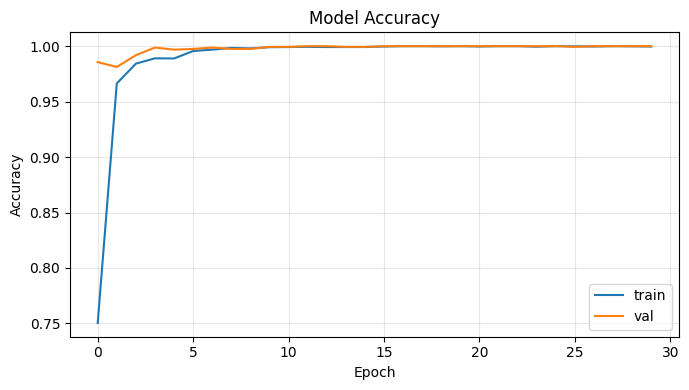

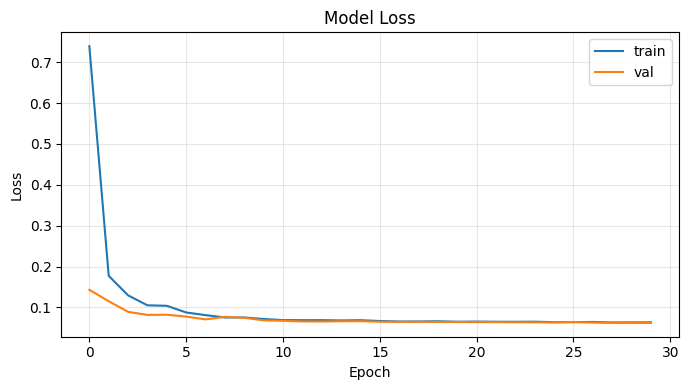


=== Test-set Evaluation (TransQ) ===
Accuracy          : 1.0000
F1 (macro)        : 1.0000
F1 (weighted)     : 1.0000
Precision (w)     : 1.0000
Recall (w)        : 1.0000
Cohen's kappa     : 1.0000
Log loss          : 0.0000
Brier (mean MSE)  : 0.000000
R² (proba)        : 1.0000
AS / HS / SC      : 1.0000 / 1.0000 / 0.0000
MSE (mean MSE)  : 0.000000
RMSE (mean RMSE)  : 0.000120
MAE (mean MAE)  : 0.000003

Critical class: Failure Stad 2 (index=4)
Recall critical   : 1.0000
FNR critical      : 0.0000

Classification report:
                  precision    recall  f1-score   support

       Very High     1.0000    1.0000    1.0000       400
            High     1.0000    1.0000    1.0000       400
High, frequently     1.0000    1.0000    1.0000       400
  Failure Stad 1     1.0000    1.0000    1.0000       400
  Failure Stad 2     1.0000    1.0000    1.0000       400

        accuracy                         1.0000      2000
       macro avg     1.0000    1.0000    1.0000      2000
   

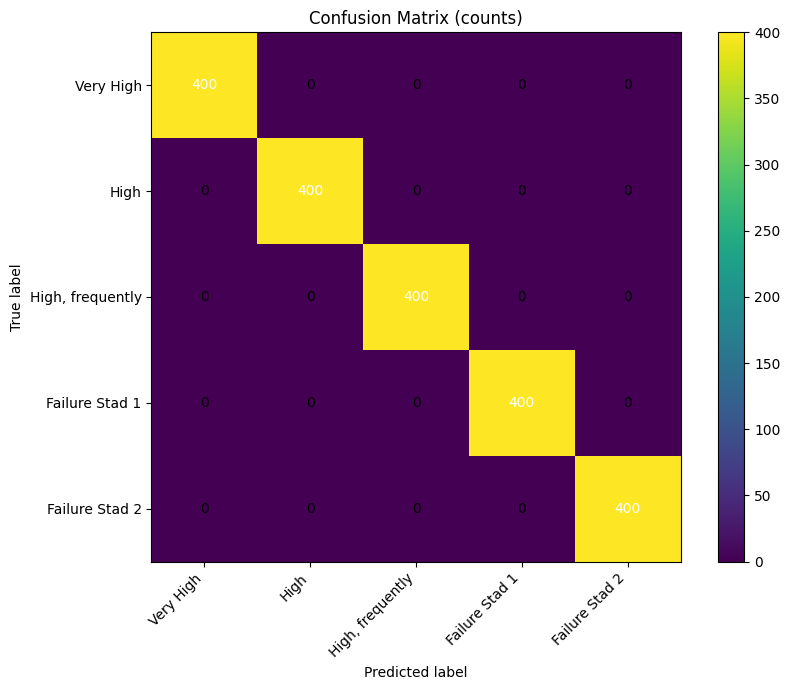

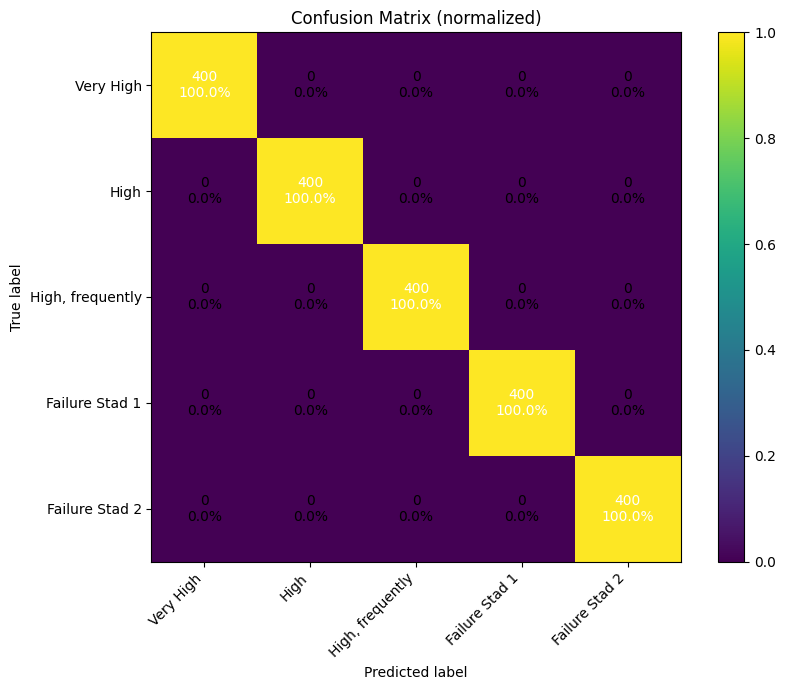


Per-class Sensitivity (SE) & Specificity (SP):
             Very High | SE=1.0000 | SP=1.0000
                  High | SE=1.0000 | SP=1.0000
      High, frequently | SE=1.0000 | SP=1.0000
        Failure Stad 1 | SE=1.0000 | SP=1.0000
        Failure Stad 2 | SE=1.0000 | SP=1.0000


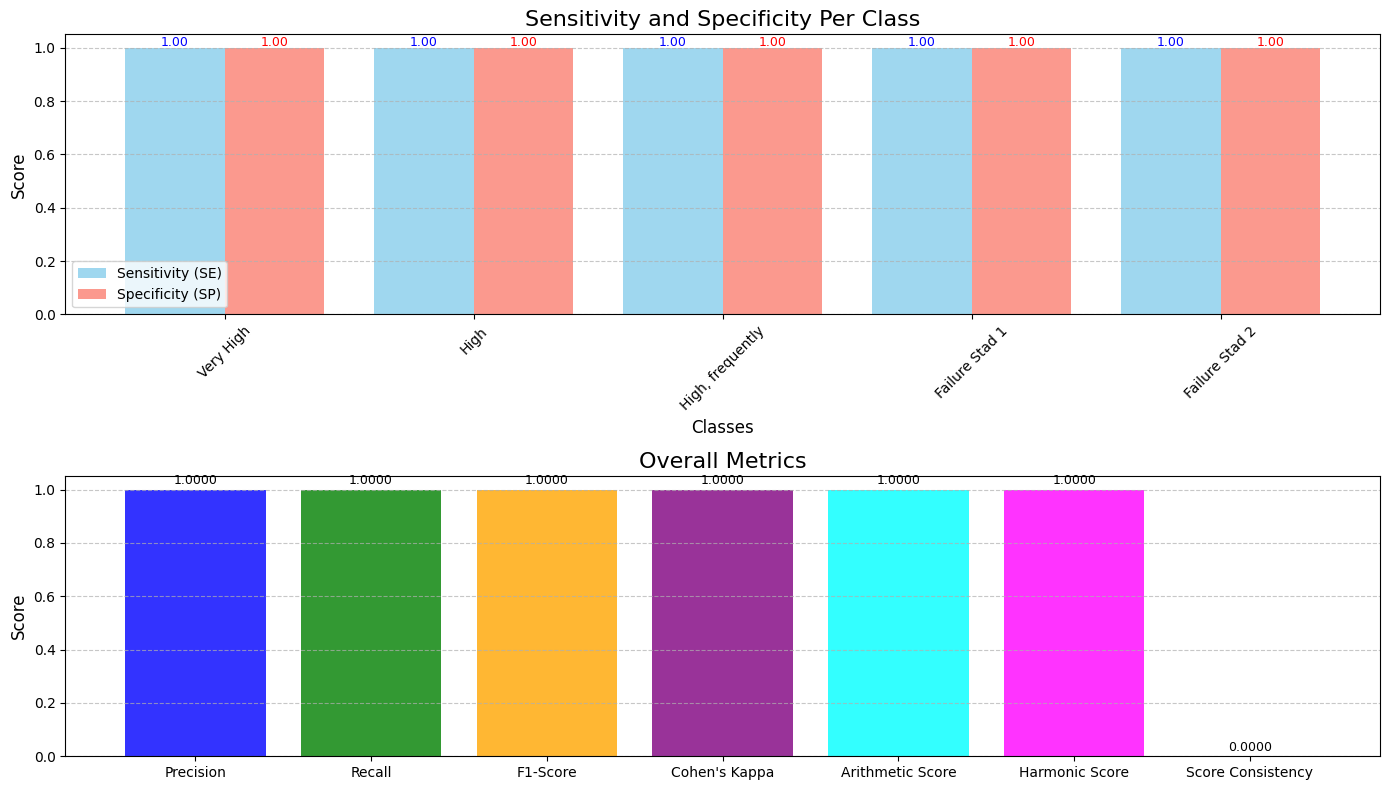

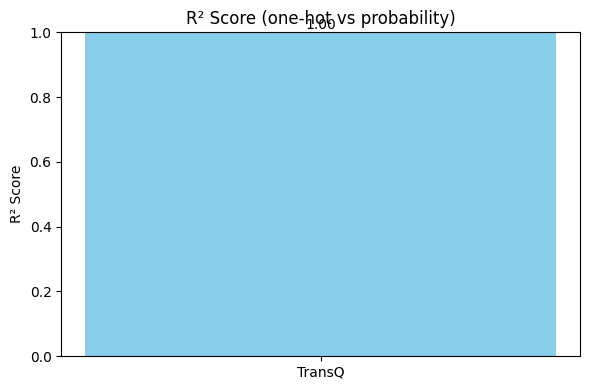

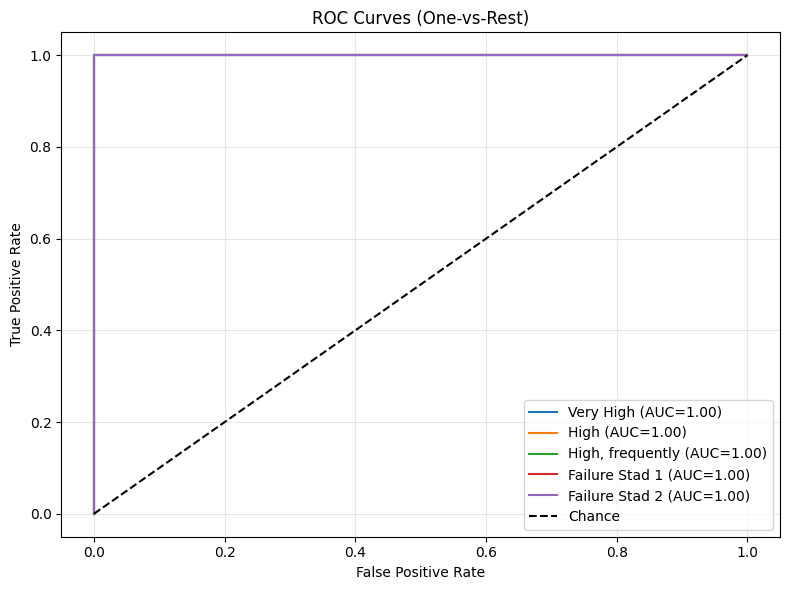

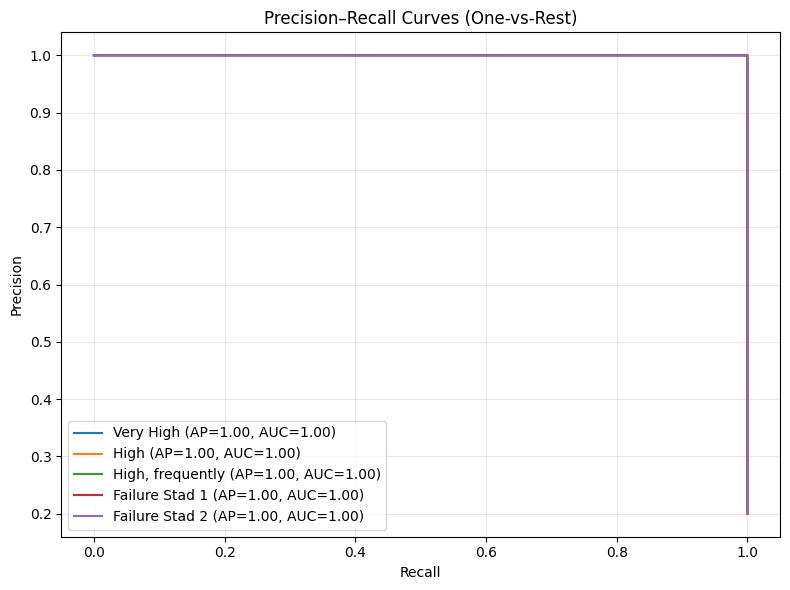


===== Fold 1/5 =====
acc=0.9992 | f1_macro=0.9992 | f1_weighted=0.9992 | logloss=0.0070 | brier=0.000319 | mse=0.000203 | rmse=0.014244 | mae=0.000276  

===== Fold 2/5 =====
acc=0.9992 | f1_macro=0.9992 | f1_weighted=0.9992 | logloss=0.0070 | brier=0.000371 | mse=0.000223 | rmse=0.014940 | mae=0.000326  

===== Fold 3/5 =====
acc=1.0000 | f1_macro=1.0000 | f1_weighted=1.0000 | logloss=0.0000 | brier=0.000000 | mse=0.000000 | rmse=0.000366 | mae=0.000015  

===== Fold 4/5 =====
acc=1.0000 | f1_macro=1.0000 | f1_weighted=1.0000 | logloss=0.0000 | brier=0.000000 | mse=0.000000 | rmse=0.000042 | mae=0.000009  

===== Fold 5/5 =====
acc=1.0000 | f1_macro=1.0000 | f1_weighted=1.0000 | logloss=0.0000 | brier=0.000000 | mse=0.000000 | rmse=0.000029 | mae=0.000002  

=== CV Summary ===
       acc: 0.9997 ± 0.0004
  f1_macro: 0.9997 ± 0.0004
f1_weighted: 0.9997 ± 0.0004
   logloss: 0.0028 ± 0.0034
     brier: 0.0001 ± 0.0002
       mse: 0.0001 ± 0.0001
      rmse: 0.0059 ± 0.0071
       mae: 0

C:\Users\user\AppData\Local\Temp\ipykernel_1732\3232958781.py:144: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


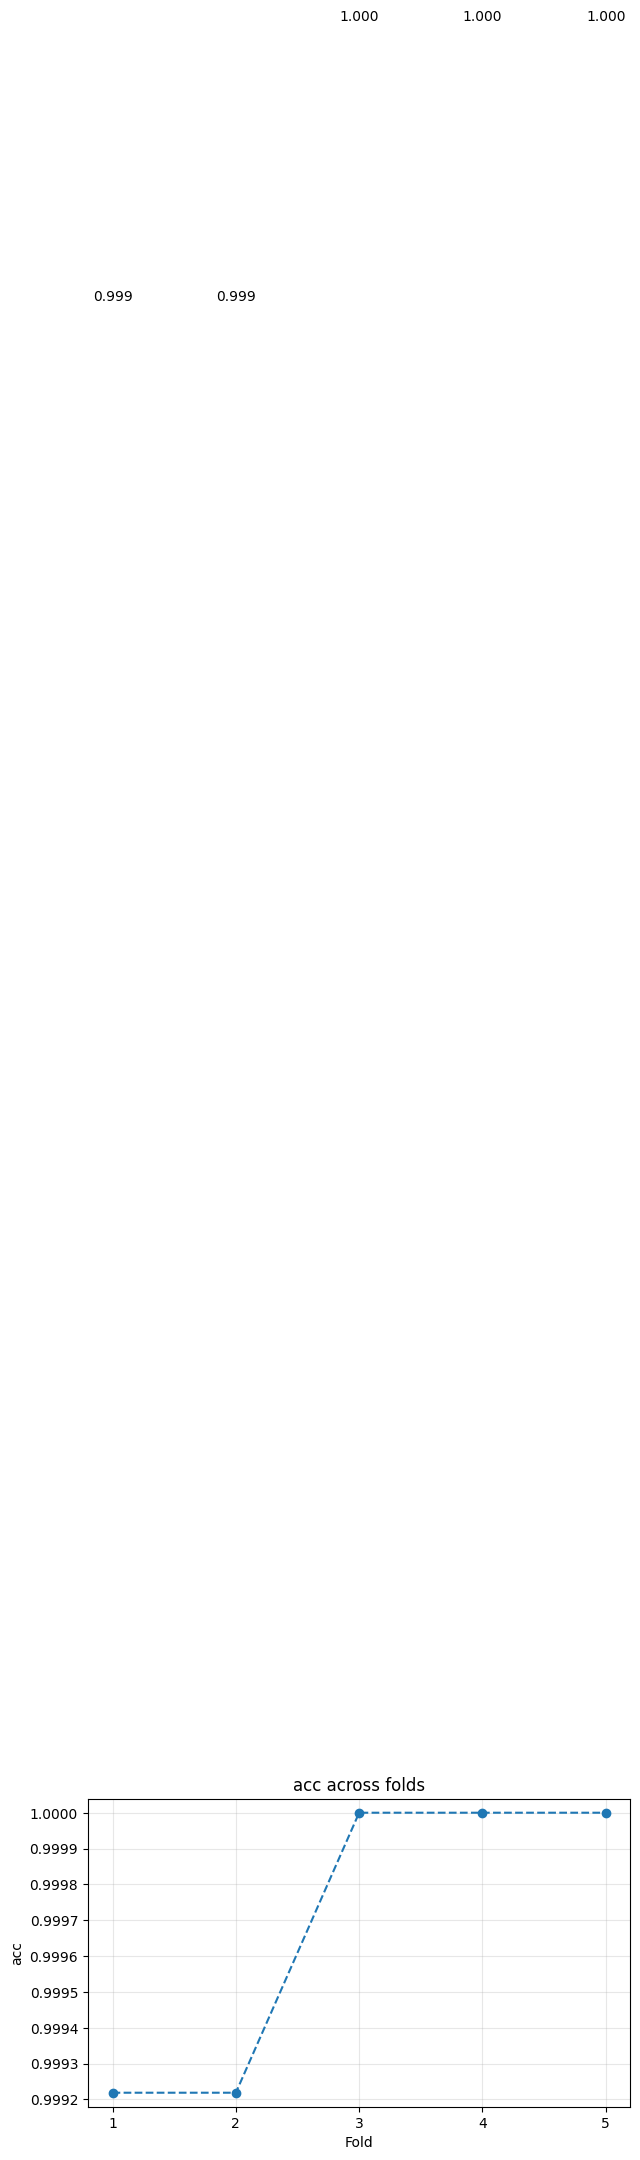

Saved: C:\Users\user\Documents\Imam_Sya_roni\Transformer2_model_new1.keras
Saved: C:\Users\user\Documents\Imam_Sya_roni\scaler_transq2.pkl
Saved: C:\Users\user\Documents\Imam_Sya_roni\label_encoder_transq2.pkl


In [4]:
#%%Cross-Validation

# =========================
# Extra helpers (AS/HS/SC + plots)
# =========================
def to_class_ids(y):
    """Accept one-hot or class-id labels -> class-id."""
    y = np.asarray(y)
    return y.argmax(axis=1) if y.ndim > 1 else y

def plot_history(history):
    # Accuracy
    plt.figure(figsize=(7, 4))
    plt.plot(history.history.get("accuracy", []), label="train")
    plt.plot(history.history.get("val_accuracy", []), label="val")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Loss
    plt.figure(figsize=(7, 4))
    plt.plot(history.history.get("loss", []), label="train")
    plt.plot(history.history.get("val_loss", []), label="val")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
def sensitivity_specificity_from_cm(cm):
    """
    Per-class Sensitivity (Recall/TPR) and Specificity (TNR).
    """
    cm = np.asarray(cm)
    K = cm.shape[0]
    se = np.zeros(K, dtype=float)
    sp = np.zeros(K, dtype=float)
    total = cm.sum()

    for i in range(K):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - (tp + fn + fp)
        se[i] = tp / (tp + fn + 1e-12)
        sp[i] = tn / (tn + fp + 1e-12)

    return se, sp

def plot_confusion_matrix(cm, class_names, normalize=True, title="Confusion Matrix"):
    cm = np.asarray(cm)
    if normalize:
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_vis = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            cm_vis = np.nan_to_num(cm_vis)
    else:
        cm_vis = cm

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm_vis, interpolation="nearest")
    fig.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=title + (" (normalized)" if normalize else " (counts)")
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # annotate: count + %
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = cm[i, j]
            if normalize:
                pct = cm_vis[i, j] * 100
                txt = f"{count}\n{pct:.1f}%"
                color = "white" if cm_vis[i, j] > 0.5 else "black"
            else:
                txt = f"{count}"
                color = "white" if cm_vis[i, j] > (cm_vis.max() / 2.0) else "black"

            ax.text(j, i, txt, ha="center", va="center", color=color)

    plt.tight_layout()
    plt.show()
    
def plot_roc_ovr(y_true_ids, y_prob, class_names):
    plt.figure(figsize=(8, 6))
    for i, name in enumerate(class_names):
        if np.sum(y_true_ids == i) == 0:
            continue
        fpr, tpr, _ = roc_curve((y_true_ids == i).astype(int), y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.title("ROC Curves (One-vs-Rest)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_pr_ovr(y_true_ids, y_prob, class_names):
    plt.figure(figsize=(8, 6))
    for i, name in enumerate(class_names):
        if np.sum(y_true_ids == i) == 0:
            continue
        p, r, _ = precision_recall_curve((y_true_ids == i).astype(int), y_prob[:, i])
        ap = average_precision_score((y_true_ids == i).astype(int), y_prob[:, i])
        pr_auc = auc(r, p)
        plt.plot(r, p, label=f"{name} (AP={ap:.2f}, AUC={pr_auc:.2f})")
    plt.title("Precision–Recall Curves (One-vs-Rest)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
def plot_cv_metric(results, key="acc"):
    vals = [r[key] for r in results]
    x = np.arange(1, len(vals) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(x, vals, marker="o", linestyle="--")
    plt.title(f"{key} across folds")
    plt.xlabel("Fold")
    plt.ylabel(key)
    plt.xticks(x)
    plt.grid(True, alpha=0.3)
    for i, v in enumerate(vals, start=1):
        plt.text(i, v + 0.005, f"{v:.3f}", ha="center")
    plt.tight_layout()
    plt.show()
    
def kfold_cv_classification(
    model_builder,   # function returning a fresh compiled model
    X,
    y_onehot,
    n_splits=5,
    epochs=30,
    batch_size=32,
    callbacks=None,
    verbose_fit=0,
    random_state=42
):
    y_ids = np.argmax(y_onehot, axis=1)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    results = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_ids), start=1):
        print(f"\n===== Fold {fold}/{n_splits} =====")

        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y_onehot[tr_idx], y_onehot[va_idx]

        # scale inside fold (fit on train only)
        scaler_fold = StandardScaler()
        X_tr_sc = scaler_fold.fit_transform(X_tr)
        X_va_sc = scaler_fold.transform(X_va)

        tf.keras.backend.clear_session()
        model = model_builder()

        model.fit(
            X_tr_sc, y_tr,
            validation_data=(X_va_sc, y_va),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=verbose_fit
        )

        # --- Standard TEST metrics (for reporting)
        y_true_test = np.argmax(y_test_oh, axis=1)
        y_prob_test = model.predict(X_test_sc, verbose=0)
        
        # =========================
        # One-hot ground truth
        # =========================
        y_true_oh = np.eye(len(class_names))[y_true_test]

        y_prob = model.predict(X_va_sc, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = np.argmax(y_va, axis=1)

        acc = accuracy_score(y_true, y_pred)
        f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
        f1w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ll  = log_loss(y_true, y_prob, labels=list(range(y_prob.shape[1])))
        mse = float(np.mean((y_true_oh - y_prob_test) ** 2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(y_true_oh - y_prob_test)))

        y_true_oh = np.eye(y_prob.shape[1])[y_true]
        brier = float(np.mean((y_true_oh - y_prob) ** 2))

        print(f"acc={acc:.4f} | f1_macro={f1m:.4f} | f1_weighted={f1w:.4f} | logloss={ll:.4f} | brier={brier:.6f} | mse={mse:.6f} | rmse={rmse:.6f} | mae={mae:.6f}  ")
        results.append({"acc": acc, "f1_macro": f1m, "f1_weighted": f1w, "logloss": ll, "brier": brier, "mse": mse,"rmse": rmse, "mae": mae})

    # aggregate
    print("\n=== CV Summary ===")
    for k in results[0].keys():
        vals = np.array([r[k] for r in results], dtype=float)
        print(f"{k:>10s}: {vals.mean():.4f} ± {vals.std():.4f}")

    return results

def calculate_as_hs_sc(se, sp):
    """
    AS (Arithmetic Score), HS (Harmonic Score), SC (Score Consistency)
    based on per-class sensitivity (SE) and specificity (SP).
    """
    se = np.asarray(se, dtype=float)
    sp = np.asarray(sp, dtype=float)

    as_score = float(np.mean((se + sp) / 2.0))
    hs_score = float(np.mean(2.0 * se * sp / (se + sp + 1e-12)))
    sc_score = float(np.std(se + sp))

    return as_score, hs_score, sc_score


def plot_se_sp_and_overall(
    class_names, se, sp,
    precision_weighted, recall_weighted, f1_weighted,
    kappa_score, arithmetic_score, harmonic_score, score_consistency
):
    # Plot Sensitivity, Specificity per Class + Overall metrics
    classes = class_names
    sensitivity = se
    specificity = sp

    plt.figure(figsize=(14, 8))

    # Subplot 1: Sensitivity and Specificity per class
    plt.subplot(2, 1, 1)
    x = np.arange(len(classes))
    bar1 = plt.bar(x - 0.2, sensitivity, width=0.4, label='Sensitivity (SE)', color='skyblue', alpha=0.8)
    bar2 = plt.bar(x + 0.2, specificity, width=0.4, label='Specificity (SP)', color='salmon', alpha=0.8)
    plt.xticks(x, classes, rotation=45)
    plt.ylim(0.0, 1.05)
    plt.title('Sensitivity and Specificity Per Class', fontsize=16)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Annotate Sensitivity and Specificity values
    for bar in bar1:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9, color='blue')
    for bar in bar2:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9, color='red')

    # Subplot 2: Overall metrics
    plt.subplot(2, 1, 2)
    metrics = ['Precision', 'Recall', 'F1-Score', "Cohen's Kappa", 'Arithmetic Score', 'Harmonic Score', 'Score Consistency']
    metric_values = [precision_weighted, recall_weighted, f1_weighted, kappa_score, arithmetic_score, harmonic_score, score_consistency]

    bar3 = plt.bar(metrics, metric_values, color=['blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'red'], alpha=0.8)
    plt.ylim(0, 1.05)
    plt.title('Overall Metrics', fontsize=16)
    plt.ylabel('Score', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Annotate Overall Metric values
    for bar in bar3:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9, color='black')

    plt.tight_layout()
    plt.show()


def plot_r2_bar(r2_value, model_name="TransQ"):
    r2_scores = {model_name: float(r2_value)}
    r2_values = list(r2_scores.values())

    plt.figure(figsize=(6, 4))
    plt.bar(r2_scores.keys(), r2_scores.values(), color='skyblue')
    plt.ylabel("R² Score")
    plt.title("R² Score (one-hot vs probability)")
    plt.ylim(0, 1)
    for i, v in enumerate(r2_values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
    plt.tight_layout()
    plt.show()

def evaluate_classifier(
    model,
    X_test_sc,
    y_test,       
    class_names,
    plot_roc_pr=True,
    critical_class_name="Failure Stad 2",
    model_name="TransQ"
):
    y_true_ids = to_class_ids(y_test)
    
    # --- Standard TEST metrics (for reporting)
    y_true_test = np.argmax(y_test_oh, axis=1)
    y_prob_test = model.predict(X_test_sc, verbose=0)
    
    # =========================
    # One-hot ground truth
    # =========================
    y_true_oh = np.eye(len(class_names))[y_true_test]

    mse = float(np.mean((y_true_oh - y_prob_test) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true_oh - y_prob_test)))

    # Predict probabilities
    y_prob = model.predict(X_test_sc, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # Basic metrics
    acc = accuracy_score(y_true_ids, y_pred)
    prec_w = precision_score(y_true_ids, y_pred, average="weighted", zero_division=0)
    rec_w  = recall_score(y_true_ids, y_pred, average="weighted", zero_division=0)
    f1_w   = f1_score(y_true_ids, y_pred, average="weighted", zero_division=0)
    f1_m   = f1_score(y_true_ids, y_pred, average="macro", zero_division=0)
    kappa  = cohen_kappa_score(y_true_ids, y_pred)

    # Probabilistic metrics
    ll = log_loss(y_true_ids, y_prob, labels=list(range(len(class_names))))
    y_true_oh = np.eye(len(class_names))[y_true_ids]
    brier = float(np.mean((y_true_oh - y_prob) ** 2))

    # R² between one-hot and prob
    r2 = float(r2_score(y_true_oh, y_prob, multioutput="variance_weighted"))

    # Confusion matrix + SE/SP
    cm = confusion_matrix(y_true_ids, y_pred, labels=np.arange(len(class_names)))
    se, sp = sensitivity_specificity_from_cm(cm)

    # AS/HS/SC
    as_score, hs_score, sc_score = calculate_as_hs_sc(se, sp)

    print("\n=== Test-set Evaluation (TransQ) ===")
    print(f"Accuracy          : {acc:.4f}")
    print(f"F1 (macro)        : {f1_m:.4f}")
    print(f"F1 (weighted)     : {f1_w:.4f}")
    print(f"Precision (w)     : {prec_w:.4f}")
    print(f"Recall (w)        : {rec_w:.4f}")
    print(f"Cohen's kappa     : {kappa:.4f}")
    print(f"Log loss          : {ll:.4f}")
    print(f"Brier (mean MSE)  : {brier:.6f}")
    print(f"R² (proba)        : {r2:.4f}")
    print(f"AS / HS / SC      : {as_score:.4f} / {hs_score:.4f} / {sc_score:.4f}")
    print(f"MSE (mean MSE)  : {mse:.6f}")
    print(f"RMSE (mean RMSE)  : {rmse:.6f}")
    print(f"MAE (mean MAE)  : {mae:.6f}")

    # Critical class recall/FNR
    if critical_class_name in class_names:
        cidx = class_names.index(critical_class_name)
        mask = (y_true_ids == cidx)
        if mask.sum() > 0:
            recall_c = float(np.mean(y_pred[mask] == cidx))
            fnr_c = float(1.0 - recall_c)
        else:
            recall_c, fnr_c = np.nan, np.nan
        print(f"\nCritical class: {critical_class_name} (index={cidx})")
        print(f"Recall critical   : {recall_c:.4f}")
        print(f"FNR critical      : {fnr_c:.4f}")
    else:
        cidx, recall_c, fnr_c = None, np.nan, np.nan

    print("\nClassification report:")
    print(classification_report(y_true_ids, y_pred, target_names=class_names, digits=4, zero_division=0))

    # Confusion matrices
    plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix")
    plot_confusion_matrix(cm, class_names, normalize=True,  title="Confusion Matrix")

    print("\nPer-class Sensitivity (SE) & Specificity (SP):")
    for i, name in enumerate(class_names):
        print(f"  {name:>20s} | SE={se[i]:.4f} | SP={sp[i]:.4f}")

    # Requested plots:
    plot_se_sp_and_overall(
        class_names=class_names,
        se=se, sp=sp,
        precision_weighted=prec_w,
        recall_weighted=rec_w,
        f1_weighted=f1_w,
        kappa_score=kappa,
        arithmetic_score=as_score,
        harmonic_score=hs_score,
        score_consistency=sc_score
    )
    plot_r2_bar(r2_value=r2, model_name=model_name)

    # ROC/PR (optional)
    if plot_roc_pr:
        plot_roc_ovr(y_true_ids, y_prob, class_names)
        plot_pr_ovr(y_true_ids, y_prob, class_names)

    return {
        "accuracy": acc,
        "f1_macro": f1_m,
        "f1_weighted": f1_w,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "kappa": kappa,
        "log_loss": ll,
        "brier": brier,
        "r2": r2,
        "as_score": as_score,
        "hs_score": hs_score,
        "sc_score": sc_score,
        "cm": cm,
        "se": se,
        "sp": sp,
        "critical_index": cidx,
        "recall_critical": recall_c,
        "fnr_critical": fnr_c
    }

plot_history(history)

class_names = ["Very High", "High", "High, frequently", "Failure Stad 1", "Failure Stad 2"]

metrics = evaluate_classifier(
    model=model,
    X_test_sc=X_test_sc,     # scaled
    y_test=y_test_oh,        # one-hot recommended
    class_names=class_names,
    plot_roc_pr=True,
    critical_class_name="Failure Stad 2",
    model_name="TransQ"
)

cv = kfold_cv_classification(
    model_builder=lambda: build_1d_transq_model(input_len=X_train_bal.shape[1], num_classes=len(class_names)),
    X=X_train_bal,
    y_onehot=y_train_oh,
    n_splits=5,
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose_fit=0
)
plot_cv_metric(cv, key="acc")

# -------------------------
# SAVE MODEL + ENCODER + SCALER
# -------------------------
import joblib


label_encoder = LabelEncoder()
label_encoder.fit(labels)

MODEL_PATH = r"C:\Users\user\Documents\Imam_Sya_roni\Transformer2_model_new1.keras"
ENC_PATH   = r"C:\Users\user\Documents\Imam_Sya_roni\label_encoder_transq2.pkl"
SCL_PATH   = r"C:\Users\user\Documents\Imam_Sya_roni\scaler_transq2.pkl"

# 1) Save model (always)
model.save(MODEL_PATH)
print("Saved:", MODEL_PATH)

# 2) Save scaler
if "scaler" in globals() and scaler is not None:
    joblib.dump(scaler, SCL_PATH)
    print("Saved:", SCL_PATH)
else:
    print(" scaler not found -> scaler not saved.")

# 3) Save label_encoder
if "label_encoder" in globals() and label_encoder is not None:
    joblib.dump(label_encoder, ENC_PATH)
    print("Saved:", ENC_PATH)
else:
    # If encoder file already exists, do not overwrite; just notify
    if os.path.exists(ENC_PATH):
        print(" label_encoder not in memory. Existing encoder file kept:", ENC_PATH)
    else:
        print(" label_encoder not found and no existing encoder file. Encoder not saved.")